# Backtest 011 — TTM Squeeze with KAMA-Centered Bands

Same machinery as **backtest_005** (TTM Breakout Squeeze: BB-vs-KC squeeze,
TTM momentum histogram, entry v1/v2/v3, ATR-trailing exits, multi-objective
Optuna), with **one change**: the **basis (middle) line of both the Bollinger
Band and the Keltner Channel is the Kaufman Adaptive Moving Average (KAMA)**
instead of an SMA (BB) and the linear-regression line (KC).

    BB = KAMA(close, bb_window) +/- bb_multiplier * STDDEV(close, bb_window)
    KC = KAMA(close, kc_window) +/- kc_multiplier * ATR

KAMA speeds up in trends and flattens in chop (efficiency-ratio adaptive), so
both envelopes track the prevailing move while filtering noise. `kama_fast` /
`kama_slow` (2 / 30) fix the adaptation bounds; `bb_window` / `kc_window` tune
the efficiency-ratio lookback. Everything else is identical to backtest_005.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os, sys, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numba as nb
import vectorbt as vbt
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import talib
ROOT = pathlib.Path('..').resolve()
sys.path.insert(0, str(ROOT))
# Numba disk cache from the FastAPI runtime stores module paths as `app.*`.
sys.path.insert(0, str(ROOT / 'backend'))
import backend.app
import backend.app.services
import backend.app.services.indicators
sys.modules.setdefault('app', backend.app)
sys.modules.setdefault('app.services', backend.app.services)
sys.modules.setdefault('app.services.indicators', backend.app.services.indicators)
from backend.app.services.indicators.trailing_sl import (
    atr_trailing_nb, atr_trailing_adaptive_nb, pearson_r_2d,
)
from backend.app.services.indicators.wiliams_vix_fix import williams_vix_fix_indicator
from backend.app.services.indicators.common import shift_2d, count_consecutive_neg_2d
from backend.app.services.indicators.kama   import kama_2d
from backend.app.services.indicators.smart_money_flow import smart_money_flow_cloud

plt.style.use('dark_background')
print('imports ok')

{'v1': {'bb_window': 23, 'bb_multiplier': 1.5, 'bb_matype': 2, 'kc_window': 21, 'kc_multiplier': 0.9, 'kc_atr_period': 5, 'donichan_window': 11, 'osc_smoothing_period': 9, 'low_stop_lookback': 5, 'atr_period': 10, 'atr_multiplier': 1.9, 'max_sl': 0.06}, 'v2': {'bb_window': 22, 'bb_multiplier': 2.0, 'bb_matype': 0, 'kc_window': 16, 'kc_multiplier': 0.8, 'kc_atr_period': 13, 'donichan_window': 11, 'osc_smoothing_period': 8, 'low_stop_lookback': 5, 'atr_period': 10, 'atr_multiplier': 2.2, 'max_sl': 0.07}, 'v3': {'bb_window': 11, 'bb_multiplier': 0.9, 'bb_matype': 0, 'kc_window': 20, 'kc_multiplier': 1.9000000000000001, 'kc_atr_period': 19, 'donichan_window': 11, 'osc_smoothing_period': 9, 'low_stop_lookback': 3, 'atr_period': 5, 'atr_multiplier': 3.5, 'max_sl': 0.14, 'william_vix_period': 18, 'consecutive_neg_threshold': 4}}
imports ok


## 1. Load Data

In [2]:
from backend.app.services.data_loader import load_stocks

BENCHMARK = 'VNINDEX'
DATA_START = '2019-01-01'

df_raw = load_stocks(exclude=['KSV', 'DVM', 'NHH'])
df_raw = df_raw.loc[DATA_START:]

open_  = df_raw['open']
high   = df_raw['high']
low    = df_raw['low']
close  = df_raw['close']
volume = df_raw['volume']

valid_syms = close.columns[close.isna().mean() < 0.2]
close  = close[valid_syms].ffill()
high   = high[valid_syms].ffill()
low    = low[valid_syms].ffill()
open_  = open_[valid_syms].ffill()
volume = volume[valid_syms].ffill().fillna(0)

if BENCHMARK in close.columns:
    bm_close  = close[BENCHMARK]
    bm_volume = volume[BENCHMARK]
else:
    bm_close  = close.mean(axis=1)
    bm_volume = volume.mean(axis=1)
    print(f'BENCHMARK {BENCHMARK!r} not found — using equal-weight index')

print(f'Shape : {close.shape}  |  {close.index[0].date()} → {close.index[-1].date()}')
print(f'Symbols: {len(valid_syms)}  |  Benchmark: {BENCHMARK}')
close.tail(3)


Loading from HDF5 cache: stocks_data_latest.h5
Shape: (2500, 970)  |  2016-07-25 → 2026-07-23
Shape : (1886, 194)  |  2019-01-02 → 2026-07-23
Symbols: 194  |  Benchmark: VNINDEX


symbol,AAA,ABB,ACB,ACV,ADS,AGG,AGR,ANV,APH,ASM,...,VNINDEX,VNM,VOS,VPB,VPG,VPI,VRE,VSC,VTP,YEG
date,,,,,,,,,,,,,,,,,,,,,
2026-07-21,6.87,17.0,22.85,39.6,7.76,11.05,13.55,17.55,5.34,5.80,...,1730.56,58.4,10.65,25.35,1.93,62.0,23.05,13.80,48.2,7.71
2026-07-22,6.68,16.9,22.40,38.8,7.65,11.05,13.60,17.15,5.31,5.59,...,1668.53,59.1,10.45,25.00,1.93,61.9,21.75,13.80,48.1,7.65
2026-07-23,6.71,16.9,22.50,39.1,7.77,11.05,13.85,17.10,5.34,5.69,...,1699.38,57.8,10.65,25.00,2.02,64.1,22.00,14.25,48.5,7.84


In [3]:
IS_FRAC   = 0.6
split_idx = int(len(close) * IS_FRAC)
oos_start = close.index[split_idx]

close_is   = close.iloc[:split_idx];  close_oos  = close.iloc[split_idx:]
high_is    = high.iloc[:split_idx];   high_oos   = high.iloc[split_idx:]
low_is     = low.iloc[:split_idx];    low_oos    = low.iloc[split_idx:]
open_is    = open_.iloc[:split_idx];  open_oos   = open_.iloc[split_idx:]
volume_is  = volume.iloc[:split_idx]; volume_oos = volume.iloc[split_idx:]

print(f'IS  {close_is.index[0].date()} → {close_is.index[-1].date()}  ({len(close_is)} bars)')
print(f'OOS {close_oos.index[0].date()} → {close_oos.index[-1].date()}  ({len(close_oos)} bars)')

IS  2019-01-02 → 2023-07-13  (1131 bars)
OOS 2023-07-14 → 2026-07-23  (755 bars)


## 2. TTM Breakout Helpers

In [4]:
def compute_signals(
    close, high, low,
    open_,
    volume,
    # BB params
    bb_window:                int   = 16,
    bb_multiplier:            float = 1.0,
    # Keltner params
    kc_window:                int   = 40,
    kc_multiplier:            float = 1.2,
    kc_atr_period:            int   = 10,
    # KAMA basis (shared BB + KC middle line)
    kama_fast:                int   = 2,
    kama_slow:                int   = 30,
    # TTM oscillator params
    donichan_window:          int   = 12,
    osc_smoothing_period:     int   = 10,
    # Entry version
    entry_version:            str   = 'v3',
    consecutive_neg_threshold:int   = 7,
    # Williams VIX Fix (v3 only)
    william_vix_period:       int   = 20,
):
    """
    Compute TTM Breakout entry signals.

    Indicators are computed lazily — only what the requested version needs:
      Both BB and KC are centred on KAMA(close, window).
      v1, v2 : BB + Keltner (both bands) + TTM histogram
      v3     : BB + Keltner (upper only) + TTM histogram + WVF
    """
    # ── always needed ──────────────────────────────────────────────────────────
    ATR  = vbt.IndicatorFactory.from_talib('ATR')
    STD  = vbt.IndicatorFactory.from_talib('STDDEV')
    SMA  = vbt.IndicatorFactory.from_talib('SMA')
    MAX  = vbt.IndicatorFactory.from_talib('MAX')
    MIN  = vbt.IndicatorFactory.from_talib('MIN')
    LREG = vbt.IndicatorFactory.from_talib('LINEARREG')

    atr = ATR.run(high, low, close, timeperiod=kc_atr_period)

    close_np    = close.to_numpy()
    atr_np      = atr.real.to_numpy()

    # BB basis = KAMA(close, bb_window); bands = basis ± bb_multiplier · STDDEV
    bb_basis_np = kama_2d(close_np.astype(np.float64), bb_window, kama_fast, kama_slow)
    bb_std_np   = STD.run(close, timeperiod=bb_window, nbdev=1.0).real.to_numpy()
    bb_upper_np = bb_basis_np + bb_multiplier * bb_std_np
    bb_lower_np = bb_basis_np - bb_multiplier * bb_std_np

    # KC basis = KAMA(close, kc_window); channel = basis ± kc_multiplier · ATR  -- backtest_011 change
    kc_basis_np = kama_2d(close_np.astype(np.float64), kc_window, kama_fast, kama_slow)
    kc_upper_np = kc_basis_np + kc_multiplier * atr_np

    hh  = MAX.run(high,  timeperiod=donichan_window).real.to_numpy()
    ll  = MIN.run(low,   timeperiod=donichan_window).real.to_numpy()
    sma = SMA.run(close, timeperiod=donichan_window).real.to_numpy()
    histogram = close_np - ((hh + ll) / 2 + sma) / 2
    ttms_np   = LREG.run(
        pd.DataFrame(histogram, index=close.index, columns=close.columns),
        timeperiod=osc_smoothing_period,
    ).real.to_numpy()

    # ── v1 / v2 only: lower Keltner band ──────────────────────────────────────
    if entry_version in ('v1', 'v2'):
        kc_lower_np = kc_basis_np - kc_multiplier * atr_np

    # ── v3 only: Williams VIX Fix ──────────────────────────────────────────────
    elif entry_version == 'v3':
        _, _, _, wvf_signal = williams_vix_fix_indicator(
            close, high, low,
            period=william_vix_period,
            mult=bb_multiplier,
            bbl=bb_window,
            lb=20, ph=0.85, ltLB=33, mtLB=10, strength_str=1,
        )
        wvf_np = wvf_signal if isinstance(wvf_signal, np.ndarray) else wvf_signal.to_numpy()



    # ── v1: no-squeeze + positive momentum ────────────────────────────────────
    if entry_version == 'v1':
        sqz_on_np  = (bb_upper_np < kc_upper_np) & (bb_lower_np > kc_lower_np)
        sqz_off_np = (bb_upper_np > kc_upper_np) & (bb_lower_np < kc_lower_np)
        no_sqz_np  = (~sqz_on_np) & (~sqz_off_np)
        entries_np = sqz_off_np & (ttms_np > 0)

    # ── v2: momentum zero-cross ───────────────────────────────────────────────
    elif entry_version == 'v2':
        sqz_on_np  = (bb_upper_np < kc_upper_np) & (bb_lower_np > kc_lower_np)
        sqz_off_np = (bb_upper_np > kc_upper_np) & (bb_lower_np < kc_lower_np)
        no_sqz_np  = (~sqz_on_np) & (~sqz_off_np)
        ttms_1 = shift_2d(ttms_np, 1)
        ttms_2 = shift_2d(ttms_np, 2)
        ttms_3 = shift_2d(ttms_np, 3)
        crossed_now  = (ttms_1 < 0) & (ttms_np > 0)
        crossed_1ago = (ttms_2 < 0) & (ttms_1  > 0)
        crossed_2ago = (ttms_3 < 0) & (ttms_2  > 0)
        cond_2 = (ttms_np > ttms_1) & crossed_1ago
        cond_3 = (ttms_np > ttms_2) & crossed_2ago
        entries_np = sqz_off_np & (crossed_now | cond_2 | cond_3)

    # ── v3: bottom-fishing + WVF contrarian ───────────────────────────────────
    else:
        squeeze_diff_np = bb_upper_np - kc_upper_np
        consec_neg      = count_consecutive_neg_2d(ttms_np)
        entry_2 = (
            (shift_2d(squeeze_diff_np, 1) < 0)
            & (squeeze_diff_np > 0)
            & (consec_neg > consecutive_neg_threshold)
        )
        entries_np = (entry_2 | wvf_np)

    return pd.DataFrame(entries_np, index=close.index, columns=close.columns)


def compute_exits(open_, close, high, low, volume, atr_period=10,
                  low_stop_lookback=5, max_sl=0.1,
                  atr_mult_min=1.5, atr_mult_max=3.5, corr_window=20,
                  fixed_mult=None, mult_mode='linear',
                  r_threshold=0.6, slope_k=0.01, r_smooth=1):
    """
    Returns (exits_df, sl_stop_df).

    exits_df:   ATR trailing-stop crossings used as explicit exit signals.
    sl_stop_df: per-bar relative stop-loss = (close - lowest_low) / close,
                hard-capped at max_sl to prevent runaway losses on breakout
                stocks where the pre-breakout base can sit 20-25% below entry.
                Pass this as sl_stop= in vbt.Portfolio.from_signals so that
                on entry the stop is placed at the swing low of the last
                low_stop_lookback bars (but no wider than max_sl).

    fixed_mult: if set, bypass the adaptive multiplier and use this constant
                ATR multiplier for every bar (ablation baseline).

    mult_mode:  how trend strength maps to the ATR multiplier scale in [0,1]:
      'linear'          : scale = clip(r, 0, 1)                    (original)
      'threshold'       : scale ramps only once r > r_threshold    (low-positive
                          r is still chop -> stays tight)
      'slope'           : scale = clip(r,0,1) * tanh(slope%/slope_k)  (linearity
                          gates, normalized slope supplies magnitude -> a flat
                          straight line no longer gets max room)
      'slope_threshold' : threshold(r) * slope strength (both refinements)
    r_threshold: knee for the threshold modes (default 0.6).
    slope_k:     fractional trend/bar that maps to ~0.76 slope strength
                 (tanh(1)); default 0.01 = 1%/bar.
    r_smooth:    EMA span (bars) applied to r before mapping; 1 = no smoothing.

    max_sl:     hard cap on the swing-low stop distance (default 8%).
                Without this cap, a breakout from a 20% consolidation base
                places the sl_stop at 20%, allowing a full -20% loss before
                the stop triggers — matching the worst-trade observations.
    """
    atr_raw = vbt.IndicatorFactory.from_talib('ATR').run(
        high, low, close, timeperiod=atr_period
    )
    # ── Adaptive multiplier via rolling Pearson correlation (price vs. time) ──
    # r measures trend linearity over `corr_window` bars:
    #   r -> +1  clean uptrend  -> WIDE stop  (let the winner run)
    #   r <= 0   chop/downtrend -> TIGHT stop (cut losers fast)
    # mult(t) = atr_mult_min + (atr_mult_max - atr_mult_min) * clip(r, 0, 1)
    try:
        close_np = close.to_numpy().astype(np.float64)
        atr_np   = atr_raw.real.to_numpy().astype(np.float64)
        if fixed_mult is not None:
            # ablation: constant multiplier everywhere
            mult_np = np.full_like(close_np, float(fixed_mult))
        else:
            r_np = pearson_r_2d(close_np, corr_window)
            if r_smooth and r_smooth > 1:
                r_np = (pd.DataFrame(r_np, index=close.index, columns=close.columns)
                        .ewm(span=r_smooth, adjust=False).mean().to_numpy())
            lin = np.clip(np.nan_to_num(r_np, nan=0.0), 0.0, 1.0)   # trend linearity (long-only)

            if mult_mode == 'linear':
                scale = lin
            elif mult_mode == 'threshold':
                scale = np.clip((lin - r_threshold) / max(1e-9, 1.0 - r_threshold), 0.0, 1.0)
            elif mult_mode in ('slope', 'slope_threshold'):
                SLOPE     = vbt.IndicatorFactory.from_talib('LINEARREG_SLOPE')
                slope_np  = SLOPE.run(close, timeperiod=corr_window).real.to_numpy()
                slope_pct = np.nan_to_num(slope_np / close_np, nan=0.0)          # trend % per bar
                slope_scl = np.clip(np.tanh(slope_pct / slope_k), 0.0, 1.0)      # long-only magnitude
                if mult_mode == 'slope':
                    scale = lin * slope_scl
                else:  # slope_threshold
                    thr   = np.clip((lin - r_threshold) / max(1e-9, 1.0 - r_threshold), 0.0, 1.0)
                    scale = thr * slope_scl
            else:
                raise ValueError(f"unknown mult_mode {mult_mode!r}")

            mult_np = atr_mult_min + (atr_mult_max - atr_mult_min) * scale
        trail_np = atr_trailing_adaptive_nb(close_np, atr_np, mult_np)
        atr_sl   = pd.DataFrame(trail_np, index=close.index, columns=close.columns)
        exits_df = close.vbt.crossed_below(atr_sl)

        MIN        = vbt.IndicatorFactory.from_talib('MIN')
        lowest_low = MIN.run(low, timeperiod=low_stop_lookback).real
        sl_stop_df = ((close - lowest_low) / close).clip(lower=0, upper=max_sl)
    except Exception as e:
        print(e)
        return pd.DataFrame(False, index=close.index, columns=close.columns), pd.DataFrame(False, index=close.index, columns=close.columns)

    return exits_df, sl_stop_df


print('Signal functions defined')

Signal functions defined


## 3. Baseline Run (default params, entry v3)

In [5]:
# VNINDEX Buy & Hold — full-sample reference
bm_oos_idx = close.index.get_loc(oos_start) if hasattr(close.index, 'get_loc') else (close.index >= oos_start).argmax()

bm_entries_full = pd.DataFrame(False, index=close.index, columns=[BENCHMARK])
bm_entries_full.iloc[0, 0] = True
bm_exits_full   = pd.DataFrame(False, index=close.index, columns=[BENCHMARK])

pf_bh_full = vbt.Portfolio.from_signals(
    close=close[[BENCHMARK]], entries=bm_entries_full, exits=bm_exits_full,
    freq='1d', group_by=['symbol'], cash_sharing=False, init_cash=100,
)
bh_total = float(pf_bh_full.total_return())
bh_sharpe = float(pf_bh_full.sharpe_ratio())
print(f'VNINDEX Buy & Hold (full)  Total Return={bh_total:.1%}  Sharpe={bh_sharpe:.3f}')


VNINDEX Buy & Hold (full)  Total Return=90.6%  Sharpe=0.650


---
## 4. Per-Version Optimisation — v1, v2, v3 Separate Studies

Each version gets its own Optuna study so parameter spaces can be tuned
independently.  v3 has extra params (`consecutive_neg_threshold`, `william_vix_period`);
v1/v2 share the same space.

| Study | Entry logic | Extra params |
|-------|------------|--------------|
| `study_v1` | `no_squeeze & TTM > 0` | — |
| `study_v2` | `no_squeeze & TTM crossed above 0` (±2 bars) | — |
| `study_v3` | squeeze released & (TTM>0 OR consec_neg>thr) OR WVF | `consecutive_neg_threshold`, `william_vix_period` |

In [6]:
def make_objective(version: str):
    """
    Returns an Optuna objective fixed to `version`.
    Objectives: (Total Return %, Sharpe Ratio)

    Parameter search space is version-specific:
      v3     : WVF + consecutive_neg included
    """

    def objective(trial):
        # ── shared across all versions ─────────────────────────────────────
        bb_window            = trial.suggest_int  ('bb_window',            10, 25)
        bb_multiplier        = trial.suggest_float('bb_multiplier',        0.8, 2.0, step=0.1)

        kc_window            = trial.suggest_int  ('kc_window',            10, 25)
        kc_multiplier        = trial.suggest_float('kc_multiplier',        0.8, 2.0, step=0.1)
        kc_atr_period        = trial.suggest_int  ('kc_atr_period',        5, 20)
        donichan_window      = 10 # trial.suggest_int  ('donichan_window',      5, 15)
        osc_smoothing_period = 10 # trial.suggest_int  ('osc_smoothing_period', 3, 15)

        low_stop_lookback    = trial.suggest_int  ('low_stop_lookback',    2, 5)
        atr_period           = trial.suggest_int  ('atr_period',           5, 20)
        atr_mult_min         = trial.suggest_float('atr_mult_min',         1.0, 2.5, step=0.1)
        atr_mult_max         = trial.suggest_float('atr_mult_max',         atr_mult_min + 0.5, 4.0, step=0.1)
        corr_window          = trial.suggest_int  ('corr_window',          10, 40, step=5)
        max_sl               = trial.suggest_float('max_sl',               0.04, 0.15, step=0.01)

        
        # ── v1 / v2: no extra signal params ────────────────────────────────
        if version in ('v1', 'v2'):
            signal_kwargs = dict()

        # ── v3 only: WVF + consecutive neg threshold ───────────────────────
        else:
            william_vix_period        = trial.suggest_int('william_vix_period',        14, 30)
            consecutive_neg_threshold = trial.suggest_int('consecutive_neg_threshold',  3, 15)
            signal_kwargs = dict(
                william_vix_period        = william_vix_period,
                consecutive_neg_threshold = consecutive_neg_threshold,
            )

        try:
            entries = compute_signals(
                close_is, high_is, low_is,
                open_=open_is, volume=volume_is,
                bb_window            = bb_window,
                bb_multiplier        = bb_multiplier,
                kc_window            = kc_window,
                kc_multiplier        = kc_multiplier,
                kc_atr_period        = kc_atr_period,
                donichan_window      = donichan_window,
                osc_smoothing_period = osc_smoothing_period,
                entry_version        = version,
                **signal_kwargs,
            )
            exits, sl_stop_df = compute_exits(
                open_is, close_is, high_is, low_is, volume_is,
                atr_period              = atr_period,
                low_stop_lookback       = low_stop_lookback,
                max_sl                  = max_sl,
                atr_mult_min            = atr_mult_min,
                atr_mult_max            = atr_mult_max,
                corr_window             = corr_window,
            )

            pf = vbt.Portfolio.from_signals(
                close=close_is, entries=entries, exits=exits,
                freq='1d', group_by=['symbol'],
                cash_sharing=False, sl_stop=sl_stop_df,
            )

            total_ret = pf.total_return().replace([np.inf, -np.inf], np.nan).dropna()
            sharpe    = pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
            sortino   = pf.sortino_ratio().replace([np.inf, -np.inf], np.nan).dropna()

            if len(total_ret) == 0:
                return -999.0, -999.0

            mean_ret    = float(total_ret.mean() * 100)
            mean_sharpe = float(sharpe.mean()) if len(sharpe) > 0 else -999.0
            mean_sortino = float(sortino.mean()) if len(sortino) > 0 else -999.0

            # penalise if <30% of symbols profitable
            if len(sharpe) > 0 and (sharpe > 0).mean() < 0.3:
                mean_ret    *= 0.5
                mean_sharpe *= 0.5

            return mean_ret, mean_sortino

        except Exception:
            return -999.0, -999.0

    return objective


N_TRIALS_PER_VERSION = 1000   # raise for better coverage

studies = {}
for ver in ['v1', 'v2', 'v3']:
    print(f'── Optimising {ver} ({N_TRIALS_PER_VERSION} trials) ──────────────────────')
    s = optuna.create_study(
        directions   = ['maximize', 'maximize'],
        study_name   = f'regkc_{ver}',
        sampler      = optuna.samplers.NSGAIISampler(seed=42),
    )
    s.optimize(make_objective(ver), n_trials=N_TRIALS_PER_VERSION,
               show_progress_bar=True)
    studies[ver] = s
    print(f'  Pareto front: {len(s.best_trials)} trials')

print('All studies done.')

── Optimising v1 (1000 trials) ──────────────────────


  0%|          | 0/1000 [00:00<?, ?it/s]

  Pareto front: 10 trials
── Optimising v2 (1000 trials) ──────────────────────


  0%|          | 0/1000 [00:00<?, ?it/s]

  Pareto front: 5 trials
── Optimising v3 (1000 trials) ──────────────────────


  0%|          | 0/1000 [00:00<?, ?it/s]

  Pareto front: 7 trials
All studies done.


## 5. Select Best Params per Version

In [7]:
SELECTION = 'balanced'   # 'best_return' | 'best_sharpe' | 'balanced'

def pick_best(study, selection=SELECTION):
    if selection == 'best_return':
        return max(study.best_trials, key=lambda t: t.values[0])
    if selection == 'best_sharpe':
        return max(study.best_trials, key=lambda t: t.values[1])
    # balanced
    def score(t):
        return 0.4 * (t.values[0] + 100) / 200 + 0.6 * (t.values[1] + 10) / 20
    return max(study.best_trials, key=score)

best_trials = {ver: pick_best(studies[ver]) for ver in ['v1', 'v2', 'v3']}
best_params = {ver: t.params for ver, t in best_trials.items()}

summary_rows = []
for ver, trial in best_trials.items():
    row = {'Version': ver,
           'Trial #': trial.number,
           'Total Return (%)': round(trial.values[0], 2),
           'Sortino':           round(trial.values[1], 3)}
    row.update(trial.params)
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('Version')
print(f'Selection strategy: {SELECTION}')
display(summary_df)


Selection strategy: balanced


,Trial #,Total Return (%),Sortino,bb_window,bb_multiplier,kc_window,kc_multiplier,kc_atr_period,low_stop_lookback,atr_period,atr_mult_min,atr_mult_max,corr_window,max_sl,william_vix_period,consecutive_neg_threshold
Version,,,,,,,,,,,,,,,,
v1,779,319.93,1.616,18,2.0,21,0.8,19,2,20,1.0,2.1,40,0.08,NaN,NaN
v2,865,297.88,1.628,25,1.9,13,0.9,6,4,18,1.8,3.7,15,0.06,NaN,NaN
v3,714,238.73,1.409,11,0.9,20,2.0,13,5,9,2.5,4.0,25,0.09,18.0,6.0


In [8]:
# Extract all optimised parameters from `summary_df` (run after optimisation cell above)
_meta_cols = {'Trial #', 'Total Return (%)', 'Sortino'}
param_cols = [c for c in summary_df.columns if c not in _meta_cols]
all_params_by_version = summary_df[param_cols].to_dict('index')

import json
print('Tunable keys ({}):'.format(len(param_cols)))
print(param_cols)
print(json.dumps(all_params_by_version, indent=2, default=str))


Tunable keys (13):
['bb_window', 'bb_multiplier', 'kc_window', 'kc_multiplier', 'kc_atr_period', 'low_stop_lookback', 'atr_period', 'atr_mult_min', 'atr_mult_max', 'corr_window', 'max_sl', 'william_vix_period', 'consecutive_neg_threshold']
{
  "v1": {
    "bb_window": 18,
    "bb_multiplier": 2.0,
    "kc_window": 21,
    "kc_multiplier": 0.8,
    "kc_atr_period": 19,
    "low_stop_lookback": 2,
    "atr_period": 20,
    "atr_mult_min": 1.0,
    "atr_mult_max": 2.1,
    "corr_window": 40,
    "max_sl": 0.08,
    "william_vix_period": NaN,
    "consecutive_neg_threshold": NaN
  },
  "v2": {
    "bb_window": 25,
    "bb_multiplier": 1.9000000000000001,
    "kc_window": 13,
    "kc_multiplier": 0.9,
    "kc_atr_period": 6,
    "low_stop_lookback": 4,
    "atr_period": 18,
    "atr_mult_min": 1.8,
    "atr_mult_max": 3.7,
    "corr_window": 15,
    "max_sl": 0.06,
    "william_vix_period": NaN,
    "consecutive_neg_threshold": NaN
  },
  "v3": {
    "bb_window": 11,
    "bb_multiplier": 0.

In [9]:
summary_df

,Trial #,Total Return (%),Sortino,bb_window,bb_multiplier,kc_window,kc_multiplier,kc_atr_period,low_stop_lookback,atr_period,atr_mult_min,atr_mult_max,corr_window,max_sl,william_vix_period,consecutive_neg_threshold
Version,,,,,,,,,,,,,,,,
v1,779,319.93,1.616,18,2.0,21,0.8,19,2,20,1.0,2.1,40,0.08,NaN,NaN
v2,865,297.88,1.628,25,1.9,13,0.9,6,4,18,1.8,3.7,15,0.06,NaN,NaN
v3,714,238.73,1.409,11,0.9,20,2.0,13,5,9,2.5,4.0,25,0.09,18.0,6.0


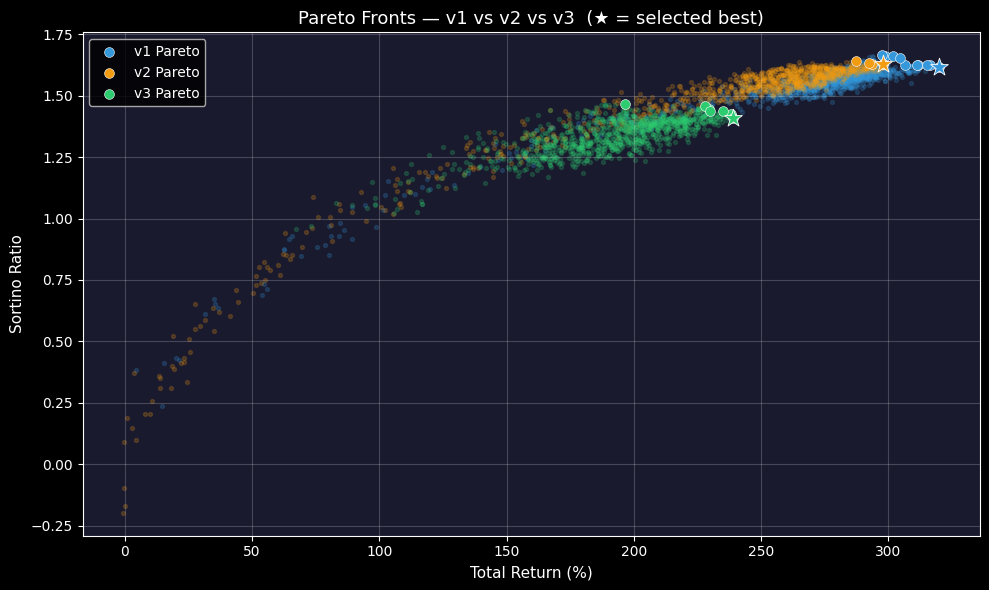

In [10]:
# ── Pareto fronts of all 3 versions on one chart ─────────────────────────────
COLORS = {'v1': '#3498db', 'v2': '#f39c12', 'v3': '#2ecc71'}

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor('#1a1a2e')

for ver, study in studies.items():
    col = COLORS[ver]
    # background: all trials
    all_vals = [(t.values[0], t.values[1]) for t in study.trials
                if t.values and t.values[0] > -900]
    if all_vals:
        ax.scatter(*zip(*all_vals), c=col, s=8, alpha=0.2)
    # Pareto front
    pf_vals = [(t.values[0], t.values[1]) for t in study.best_trials]
    ax.scatter(*zip(*pf_vals), c=col, s=50, zorder=5,
               edgecolors='white', linewidths=0.4, label=f'{ver} Pareto')
    # best point
    bt = best_trials[ver]
    ax.scatter(bt.values[0], bt.values[1], c=col, s=180, marker='*',
               zorder=6, edgecolors='white', linewidths=0.6)

ax.set_xlabel('Total Return (%)', fontsize=11)
ax.set_ylabel('Sortino Ratio',     fontsize=11)
ax.set_title('Pareto Fronts — v1 vs v2 vs v3  (★ = selected best)', fontsize=13)
ax.legend(fontsize=10)
ax.yaxis.grid(True, alpha=0.2); ax.xaxis.grid(True, alpha=0.2)
fig.tight_layout(); plt.show()


## 6. Final Backtest — Optimised v1 vs v2 vs v3

In [11]:
# OOS evaluation — params found on IS, evaluated on held-out OOS slice.
# Baseline: VNINDEX Buy & Hold on OOS (the passive benchmark to beat).

# ── VNINDEX Buy & Hold on OOS ─────────────────────────────────────────────────
bm_entries_oos = pd.DataFrame(False, index=close_oos.index, columns=[BENCHMARK])
bm_entries_oos.iloc[0, 0] = True
bm_exits_oos   = pd.DataFrame(False, index=close_oos.index, columns=[BENCHMARK])

pf_base = vbt.Portfolio.from_signals(
    close=close_oos[[BENCHMARK]], entries=bm_entries_oos, exits=bm_exits_oos,
    freq='1d', group_by=['symbol'], cash_sharing=False, init_cash=100,
)
bh_sharpe_oos = float(np.atleast_1d(pf_base.sharpe_ratio())[0])
bh_ret_oos    = float(np.atleast_1d(pf_base.total_return())[0])
print(f'VNINDEX Buy & Hold (OOS)  Total Return={bh_ret_oos:.1%}  Sharpe={bh_sharpe_oos:.3f}')

# ── OOS optimised (IS params applied to OOS) ──────────────────────────────────
portfolios = {}

for ver in ['v1', 'v2', 'v3']:
    p  = best_params[ver]
    print(f'Running optimised {ver} on OOS …')
    entries = compute_signals(
        close_oos, high_oos, low_oos,
        open_oos, volume_oos,
        bb_window                = p['bb_window'],
        bb_multiplier            = p['bb_multiplier'],
        kc_window                = p['kc_window'],
        kc_multiplier            = p['kc_multiplier'],
        kc_atr_period            = p['kc_atr_period'],
        donichan_window          = p.get('donichan_window', 10),
        osc_smoothing_period     = p.get('osc_smoothing_period', 10),
        entry_version            = ver,
        consecutive_neg_threshold= p.get('consecutive_neg_threshold', 7),
        william_vix_period       = p.get('william_vix_period',        20),
    )
    exits, sl_stop_df = compute_exits(
        open_oos, close_oos, high_oos, low_oos, volume_oos,
        atr_period        = p['atr_period'],
        low_stop_lookback = p['low_stop_lookback'],
        max_sl            = p.get('max_sl', 0.08),
        atr_mult_min      = p.get('atr_mult_min', 1.5),
        atr_mult_max      = p.get('atr_mult_max', 3.5),
        corr_window       = p.get('corr_window', 20),
        r_smooth          = p.get('r_smooth', 5),
    )
    pf = vbt.Portfolio.from_signals(
        close=close_oos, entries=entries, exits=exits,
        freq='1d', group_by=['symbol'],
        cash_sharing=False, sl_stop=sl_stop_df,
    )
    portfolios[ver] = pf
    print(f'  {ver}  Sharpe={pf.sharpe_ratio().mean():.3f}  '
          f'vs VNINDEX {bh_sharpe_oos:.3f}  '
          f'(Δ{pf.sharpe_ratio().mean()-bh_sharpe_oos:+.3f})')

print('\nAll OOS portfolios built.')

VNINDEX Buy & Hold (OOS)  Total Return=45.4%  Sharpe=0.919
Running optimised v1 on OOS …
  v1  Sharpe=0.213  vs VNINDEX 0.919  (Δ-0.707)
Running optimised v2 on OOS …
  v2  Sharpe=0.300  vs VNINDEX 0.919  (Δ-0.620)
Running optimised v3 on OOS …
  v3  Sharpe=0.377  vs VNINDEX 0.919  (Δ-0.542)

All OOS portfolios built.


## 7. Comparison — Stats Table

In [12]:
def version_stats(ver, pf):
    def _s(x):
        return pd.Series(np.atleast_1d(x), dtype=float)

    s  = _s(pf.sharpe_ratio()).replace([np.inf, -np.inf], np.nan).dropna()
    tr = _s(pf.total_return())
    dd = _s(pf.max_drawdown())

    try:
        n_trades  = int(pf.trades.count().sum())
        avg_ret   = f'{_s(pf.trades.returns.mean()).mean():.2%}'
        win_rate  = f'{_s(pf.trades.win_rate()).mean():.1%}'
        pf_factor = round(_s(pf.trades.profit_factor()).mean(), 3)
    except Exception:
        n_trades  = 0
        avg_ret   = 'N/A'
        win_rate  = 'N/A'
        pf_factor = float('nan')

    return {
        'Version':          ver,
        'Sharpe mean':      round(s.mean(), 3),
        'Sharpe median':    round(s.median(), 3),
        'Sharpe > 0':       f'{(s > 0).sum()}/{len(s)}',
        'Sharpe > 1':       f'{(s > 1).sum()}/{len(s)}',
        'Sortino mean':     round(_s(pf.sortino_ratio()).replace([np.inf,-np.inf],np.nan).dropna().mean(), 3),
        'Calmar mean':      round(_s(pf.calmar_ratio()).replace([np.inf,-np.inf],np.nan).dropna().mean(), 3),
        'Total Ret mean':   f'{tr.mean():.1%}',
        'Total Ret median': f'{tr.median():.1%}',
        'Max DD mean':      f'{dd.mean():.1%}',
        'Max DD worst':     f'{dd.min():.1%}',
        'N Trades':         n_trades,
        'Avg Trade Ret':    avg_ret,
        'Win Rate':         win_rate,
        'Profit Factor':    pf_factor,
    }

rows = [version_stats(ver, pf) for ver, pf in portfolios.items()]
rows.insert(0, version_stats('VNINDEX Buy & Hold', pf_base))

comp_df = pd.DataFrame(rows).set_index('Version')
print('=== VERSION COMPARISON ===')
display(comp_df.T)

=== VERSION COMPARISON ===


Version,VNINDEX Buy & Hold,v1,v2,v3
Sharpe mean,0.919,0.213,0.3,0.377
Sharpe median,0.919,0.189,0.196,0.377
Sharpe > 0,1/1,122/194,130/194,145/194
Sharpe > 1,0/1,22/194,28/194,27/194
Sortino mean,1.237,0.361,0.49,0.602
Calmar mean,1.097,0.261,0.352,0.388
Total Ret mean,45.4%,17.7%,23.8%,26.9%
Total Ret median,45.4%,0.8%,3.5%,15.0%
Max DD mean,-18.1%,-37.3%,-35.1%,-33.5%
Max DD worst,-18.1%,-63.6%,-67.9%,-58.9%


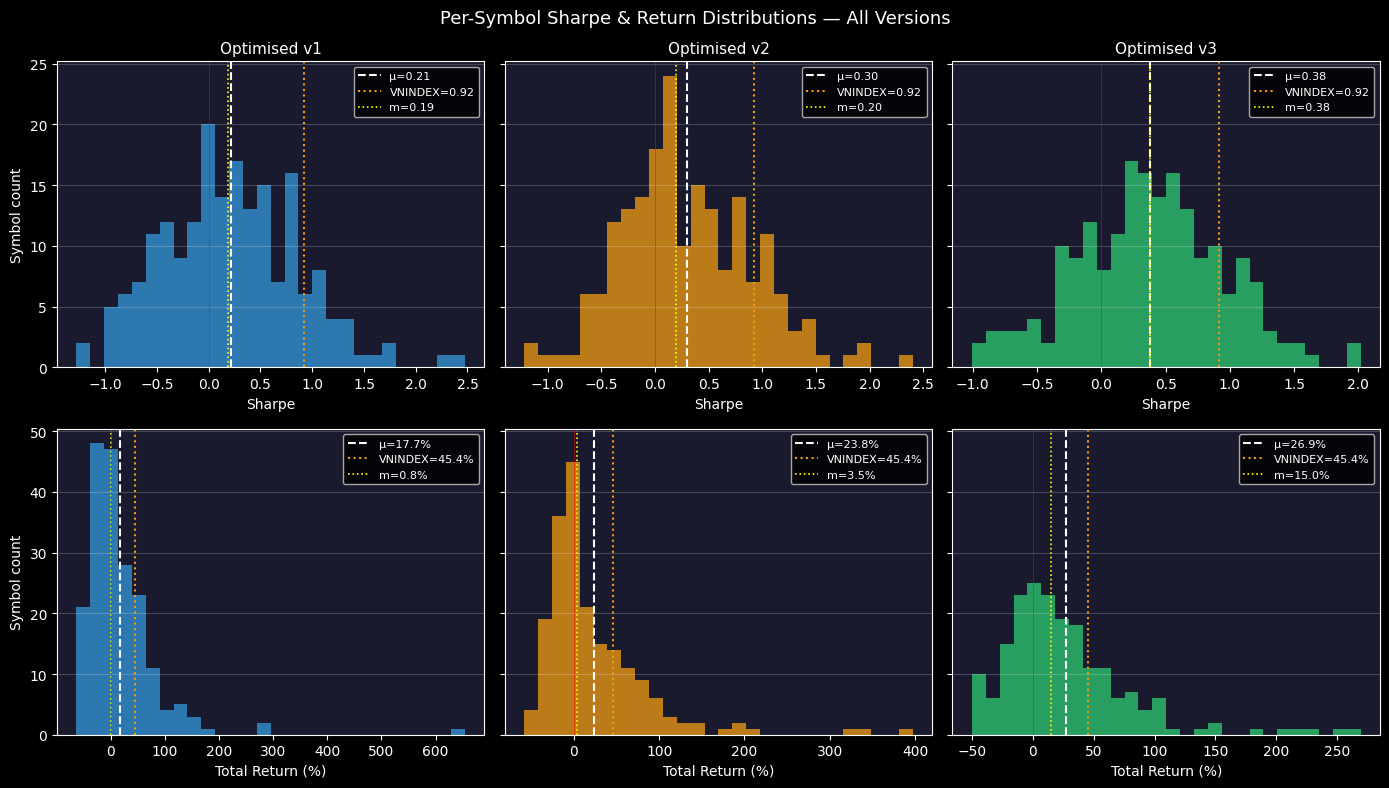

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey='row')

entries_list = [(f'Optimised {ver}', portfolios[ver], COLORS[ver])
    for ver in ['v1', 'v2', 'v3']]
bh_sharpe_ref = float(np.atleast_1d(pf_base.sharpe_ratio())[0])
bh_ret_ref    = float(np.atleast_1d(pf_base.total_return())[0]) * 100

for col_i, (name, pf, col) in enumerate(entries_list):
    ax_sh = axes[0, col_i]
    sv = pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
    ax_sh.set_facecolor('#1a1a2e')
    ax_sh.hist(sv, bins=28, color=col, alpha=0.75, edgecolor='none')
    ax_sh.axvline(sv.mean(), color='white', lw=1.5, ls='--',
                  label=f'μ={sv.mean():.2f}')
    ax_sh.axvline(bh_sharpe_ref, color='#f39c12', lw=1.5, ls=':',
                  label=f'VNINDEX={bh_sharpe_ref:.2f}')
    ax_sh.axvline(sv.median(), color='yellow', lw=1.2, ls=':',
                  label=f'm={sv.median():.2f}')
    ax_sh.axvline(0, color='red', lw=0.7, alpha=0.5)
    ax_sh.set_title(name, fontsize=11)
    ax_sh.set_xlabel('Sharpe')
    ax_sh.legend(fontsize=8)
    ax_sh.yaxis.grid(True, alpha=0.2)

    ax_rt = axes[1, col_i]
    rv = pf.total_return().replace([np.inf, -np.inf], np.nan).dropna() * 100
    ax_rt.set_facecolor('#1a1a2e')
    ax_rt.hist(rv, bins=28, color=col, alpha=0.75, edgecolor='none')
    ax_rt.axvline(rv.mean(), color='white', lw=1.5, ls='--',
                  label=f'μ={rv.mean():.1f}%')
    ax_rt.axvline(bh_ret_ref, color='#f39c12', lw=1.5, ls=':',
                  label=f'VNINDEX={bh_ret_ref:.1f}%')
    ax_rt.axvline(rv.median(), color='yellow', lw=1.2, ls=':',
                  label=f'm={rv.median():.1f}%')
    ax_rt.axvline(0, color='red', lw=0.7, alpha=0.5)
    ax_rt.set_xlabel('Total Return (%)')
    ax_rt.legend(fontsize=8)
    ax_rt.yaxis.grid(True, alpha=0.2)

axes[0, 0].set_ylabel('Symbol count')
axes[1, 0].set_ylabel('Symbol count')
fig.suptitle('Per-Symbol Sharpe & Return Distributions — All Versions', fontsize=13)
fig.tight_layout(); plt.show()


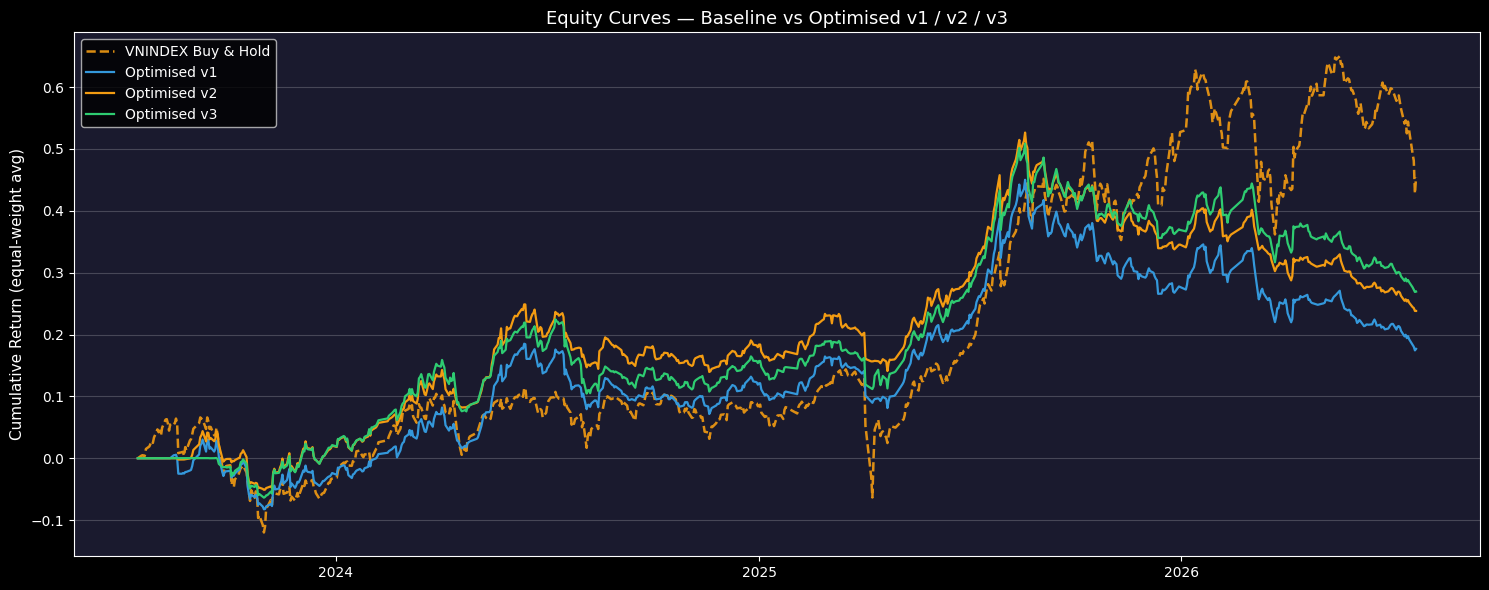

In [14]:
fig, ax = plt.subplots(figsize=(15, 6))
ax.set_facecolor('#1a1a2e')

# pf_base is single-symbol: cumulative_returns() returns a Series, not DataFrame
_bh_cum = pf_base.cumulative_returns()
bh_cum = _bh_cum if isinstance(_bh_cum, pd.Series) else _bh_cum.mean(axis=1)
ax.plot(bh_cum.index, bh_cum.values,
        color='#f39c12', lw=1.8, ls='--', label='VNINDEX Buy & Hold', alpha=0.9)

for ver, pf in portfolios.items():
    cum = pf.cumulative_returns().mean(axis=1)
    ax.plot(cum.index, cum.values, label=f'Optimised {ver}',
            color=COLORS[ver], lw=1.6)

ax.set_ylabel('Cumulative Return (equal-weight avg)', fontsize=11)
ax.set_title('Equity Curves — Baseline vs Optimised v1 / v2 / v3', fontsize=13)
ax.legend(fontsize=10); ax.yaxis.grid(True, alpha=0.2)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.tight_layout(); plt.show()

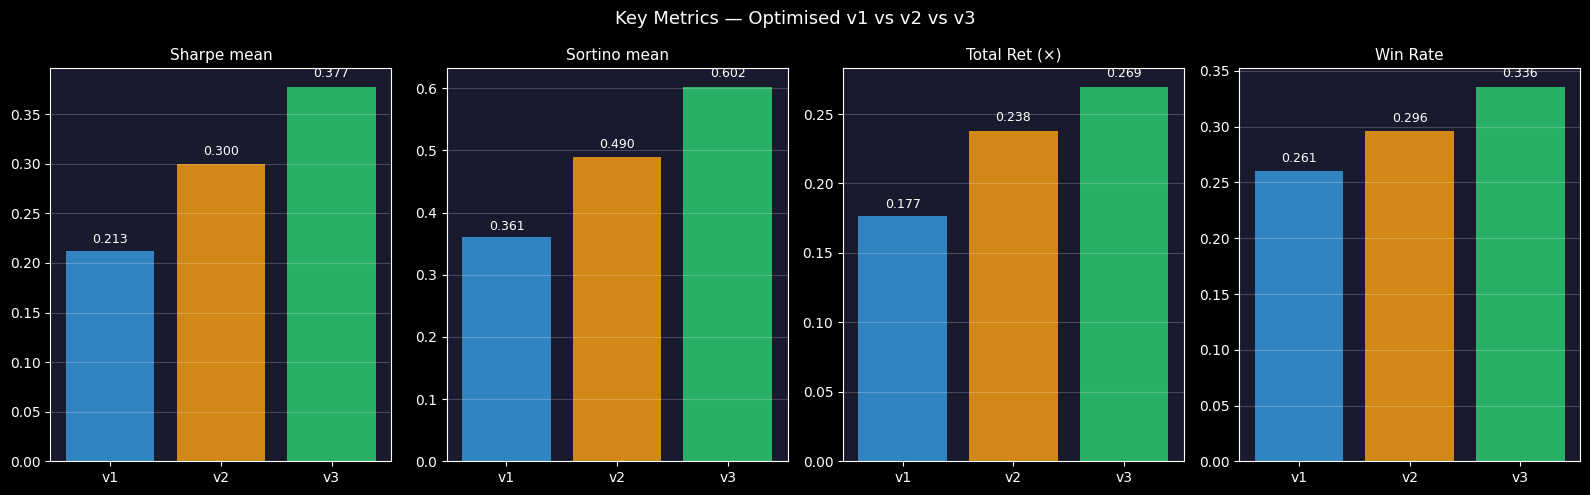

In [15]:
# ── grouped bar chart: Sharpe mean, Sortino mean, Total Ret mean ──────────────
versions  = ['v1', 'v2', 'v3']
metrics   = {
    'Sharpe mean':  [portfolios[v].sharpe_ratio().replace([np.inf,-np.inf],np.nan).dropna().mean()
                     for v in versions],
    'Sortino mean': [portfolios[v].sortino_ratio().replace([np.inf,-np.inf],np.nan).dropna().mean()
                     for v in versions],
    'Total Ret (×)': [portfolios[v].total_return().mean() for v in versions],
    'Win Rate':     [portfolios[v].trades.win_rate().mean() for v in versions],
}

x   = np.arange(len(versions))
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, (metric, vals) in zip(axes, metrics.items()):
    colors = [COLORS[v] for v in versions]
    bars   = ax.bar(versions, vals, color=colors, edgecolor='none', alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                val + abs(val) * 0.02,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(metric, fontsize=11)
    ax.axhline(0, color='white', lw=0.6, alpha=0.5)
    ax.yaxis.grid(True, alpha=0.2)
    ax.set_facecolor('#1a1a2e')

fig.suptitle('Key Metrics — Optimised v1 vs v2 vs v3', fontsize=13)
fig.tight_layout(); plt.show()


In [16]:
# ── final scorecard ───────────────────────────────────────────────────────────
print('=' * 62)
print('  FINAL SCORECARD — OPTIMISED v1 / v2 / v3')
print('=' * 62)
print(f'  {"Version":<12}  {"Sharpe μ":>9}  {"Sortino μ":>10}  {"Total Ret μ":>12}  {"Win Rate":>9}')
print('  ' + '-' * 58)

bh_sh = float(np.atleast_1d(pf_base.sharpe_ratio())[0])
bh_so = float(np.atleast_1d(pf_base.sortino_ratio())[0])
bh_tr = float(np.atleast_1d(pf_base.total_return())[0])
print(f'  {"VNINDEX B&H":<12}  {bh_sh:>9.3f}  {bh_so:>10.3f}  {bh_tr:>11.1%}  {"N/A":>9}')
print('  ' + '-' * 58)

scores = []
for ver, pf in portfolios.items():
    sh = pf.sharpe_ratio().replace([np.inf,-np.inf],np.nan).dropna().mean()
    so = pf.sortino_ratio().replace([np.inf,-np.inf],np.nan).dropna().mean()
    tr = pf.total_return().mean()
    wr = pf.trades.win_rate().mean()
    scores.append((ver, sh, so, tr, wr))
    print(f'  {ver:<12}  {sh:>9.3f}  {so:>10.3f}  {tr:>12.1%}  {wr:>9.1%}')

print('=' * 62)
best_ver = max(scores, key=lambda x: x[1])
print(f'\n  Best Sharpe  → {best_ver[0]}  ({best_ver[1]:.3f})')
best_ret = max(scores, key=lambda x: x[3])
print(f'  Best Return  → {best_ret[0]}  ({best_ret[3]:.1%})')
best_so  = max(scores, key=lambda x: x[2])
print(f'  Best Sortino → {best_so[0]}  ({best_so[2]:.3f})')


  FINAL SCORECARD — OPTIMISED v1 / v2 / v3
  Version        Sharpe μ   Sortino μ   Total Ret μ   Win Rate
  ----------------------------------------------------------
  VNINDEX B&H       0.919       1.237        45.4%        N/A
  ----------------------------------------------------------
  v1                0.213       0.361         17.7%      26.1%
  v2                0.300       0.490         23.8%      29.6%
  v3                0.377       0.602         26.9%      33.6%

  Best Sharpe  → v3  (0.377)
  Best Return  → v3  (26.9%)
  Best Sortino → v3  (0.602)


## 7.5 Ablation — r-Adaptive Multiplier vs Fixed Constant (OOS)

Does the Pearson-r adaptive ATR multiplier actually earn its complexity?
Same entries, same `sl_stop`, same ATR — **only** the trailing-stop multiplier
source changes (r-driven ramp vs a constant). If the adaptive version doesn't
beat the best fixed constant on the held-out OOS slice, the machinery is dead
weight and should be dropped for a single tuned constant.

In [17]:
# ── Ablation: r-adaptive multiplier vs fixed constant (OOS) ───────────────────
ABL_VER    = 'v2'                       # optimised version to ablate
FIXED_GRID = [1.5, 1.8, 2.0, 2.5]  # constant multipliers to test
p = best_params[ABL_VER]

# entries are identical across all configs — compute once
_entries_abl = compute_signals(
    close_oos, high_oos, low_oos, open_oos, volume_oos,
    bb_window=p['bb_window'], bb_multiplier=p['bb_multiplier'],
    kc_window=p['kc_window'], kc_multiplier=p['kc_multiplier'],
    kc_atr_period=p['kc_atr_period'],
    donichan_window=p.get('donichan_window', 10),
    osc_smoothing_period=p.get('osc_smoothing_period', 10),
    entry_version=ABL_VER,
    consecutive_neg_threshold=p.get('consecutive_neg_threshold', 7),
    william_vix_period=p.get('william_vix_period', 20),
)

def _build_abl(fixed_mult):
    exits, sl = compute_exits(
        open_oos, close_oos, high_oos, low_oos, volume_oos,
        atr_period=p['atr_period'], low_stop_lookback=p['low_stop_lookback'],
        max_sl=p.get('max_sl', 0.08),
        atr_mult_min=p.get('atr_mult_min', 1.5), atr_mult_max=p.get('atr_mult_max', 3.5),
        corr_window=p.get('corr_window', 20),
        fixed_mult=fixed_mult,          # None -> r-adaptive
    )
    return vbt.Portfolio.from_signals(
        close=close_oos, entries=_entries_abl, exits=exits,
        freq='1d', group_by=['symbol'], cash_sharing=False, sl_stop=sl,
    )

def _metrics_abl(pf):
    sh = pf.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna()
    so = pf.sortino_ratio().replace([np.inf, -np.inf], np.nan).dropna()
    return {
        'sharpe':  sh.mean(),
        'sortino': so.mean(),
        'ret_%':   pf.total_return().mean() * 100,
        'maxdd_%': pf.max_drawdown().mean() * 100,
        'trades':  int(pf.trades.count().sum()),
    }

rows = []
m = _metrics_abl(_build_abl(None)); m['config'] = 'r-adaptive'; rows.append(m)
for fm in FIXED_GRID:
    m = _metrics_abl(_build_abl(fm)); m['config'] = f'fixed {fm:.1f}'; rows.append(m)

abl_df = (pd.DataFrame(rows)
          .set_index('config')[['sharpe', 'sortino', 'ret_%', 'maxdd_%', 'trades']])

adaptive       = abl_df.loc['r-adaptive']
best_fixed_cfg = abl_df.drop('r-adaptive')['sharpe'].idxmax()
best_fixed     = abl_df.loc[best_fixed_cfg]
d_sharpe       = adaptive['sharpe'] - best_fixed['sharpe']

print(f'OOS ablation — cross-sectional means, version {ABL_VER}')
print('=' * 60)
print(abl_df.to_string(float_format=lambda x: f'{x:8.3f}'))
print('=' * 60)
print(f'r-adaptive Sharpe {adaptive["sharpe"]:.3f}  vs  '
      f'best fixed [{best_fixed_cfg}] {best_fixed["sharpe"]:.3f}   '
      f'-> delta {d_sharpe:+.3f}')
print('Verdict:',
      'r-adaptive EARNS its complexity (beats best constant on OOS).' if d_sharpe > 0
      else 'r-adaptive does NOT beat the best fixed constant — consider dropping it.')


OOS ablation — cross-sectional means, version v2
             sharpe  sortino    ret_%  maxdd_%  trades
config                                                
r-adaptive    0.281    0.460   22.269  -35.881    3745
fixed 1.5     0.195    0.353   15.036  -32.539    5117
fixed 1.8     0.209    0.370   16.927  -34.031    4725
fixed 2.0     0.233    0.402   18.812  -34.508    4470
fixed 2.5     0.239    0.403   19.485  -36.044    3969
r-adaptive Sharpe 0.281  vs  best fixed [fixed 2.5] 0.239   -> delta +0.042
Verdict: r-adaptive EARNS its complexity (beats best constant on OOS).


## 7.6 Multiplier-Mode Refinements (OOS)

Test the mapping refinements against the original `linear` ramp — all reuse the
Section-7.5 entries, `sl_stop`, and tuned params, so only the trend-strength ->
multiplier mapping changes:

- **threshold** — widen only once `r > r_threshold`; low-positive r (still chop) stays tight.
- **slope-gated** — linearity gates, normalized slope supplies magnitude, so a flat-but-straight drift no longer earns max room.
- **slope + threshold** — both refinements stacked.
- **linear + r-smooth5** — EMA-smoothed r to damp bar-to-bar jumpiness.

`best fixed` from 7.5 is carried in as the do-nothing reference to beat.

In [18]:
# ── Refinement sweep: multiplier-mapping modes (OOS) ──────────────────────────
# Requires Section 7.5 (defines p, _entries_abl, _build_abl, _metrics_abl,
# best_fixed_cfg). Reuses the same version + entries.
REF_VER = ABL_VER
MODES = [
    dict(label='linear (baseline)', mult_mode='linear'),
    dict(label='threshold r>0.6',   mult_mode='threshold',       r_threshold=0.6),
    dict(label='slope-gated',       mult_mode='slope',           slope_k=0.01),
    dict(label='slope+threshold',   mult_mode='slope_threshold', r_threshold=0.6, slope_k=0.01),
    dict(label='linear + r-smooth5',mult_mode='linear',          r_smooth=5),
]

def _build_mode(**kw):
    exits, sl = compute_exits(
        open_oos, close_oos, high_oos, low_oos, volume_oos,
        atr_period=p['atr_period'], low_stop_lookback=p['low_stop_lookback'],
        max_sl=p.get('max_sl', 0.08),
        atr_mult_min=p.get('atr_mult_min', 1.5), atr_mult_max=p.get('atr_mult_max', 3.5),
        corr_window=p.get('corr_window', 20),
        **kw,
    )
    return vbt.Portfolio.from_signals(
        close=close_oos, entries=_entries_abl, exits=exits,
        freq='1d', group_by=['symbol'], cash_sharing=False, sl_stop=sl,
    )

rows = []
for cfg in MODES:
    kw = {k: v for k, v in cfg.items() if k != 'label'}
    m = _metrics_abl(_build_mode(**kw)); m['config'] = cfg['label']; rows.append(m)

# do-nothing reference: best fixed constant from 7.5
best_fixed_mult = float(best_fixed_cfg.split()[-1])
m = _metrics_abl(_build_abl(best_fixed_mult))
m['config'] = f'best fixed ({best_fixed_cfg})'; rows.append(m)

ref_df = (pd.DataFrame(rows)
          .set_index('config')[['sharpe', 'sortino', 'ret_%', 'maxdd_%', 'trades']])
base_sh = ref_df.loc['linear (baseline)', 'sharpe']
ref_df['dSharpe'] = ref_df['sharpe'] - base_sh   # vs linear baseline

print(f'OOS multiplier-mode refinements — version {REF_VER}')
print('=' * 74)
print(ref_df.to_string(float_format=lambda x: f'{x:8.3f}'))
print('=' * 74)

_modes_only = ref_df.drop(index=[c for c in ref_df.index if c.startswith('best fixed')])
best_mode   = _modes_only['sharpe'].idxmax()
print(f'Best adaptive mode by Sharpe: {best_mode}  ({ref_df.loc[best_mode, "sharpe"]:.3f}, '
      f'{ref_df.loc[best_mode, "dSharpe"]:+.3f} vs linear)')
print(f'Best mode vs best fixed constant: '
      f'{ref_df.loc[best_mode, "sharpe"] - ref_df.loc[f"best fixed ({best_fixed_cfg})", "sharpe"]:+.3f}')


OOS multiplier-mode refinements — version v2
                         sharpe  sortino    ret_%  maxdd_%  trades  dSharpe
config                                                                     
linear (baseline)         0.281    0.460   22.269  -35.881    3745    0.000
threshold r>0.6           0.279    0.464   22.025  -34.517    4204   -0.002
slope-gated               0.258    0.429   20.302  -35.077    4170   -0.023
slope+threshold           0.262    0.441   21.230  -34.616    4359   -0.019
linear + r-smooth5        0.300    0.490   23.813  -35.132    3896    0.019
best fixed (fixed 2.5)    0.239    0.403   19.485  -36.044    3969   -0.042
Best adaptive mode by Sharpe: linear + r-smooth5  (0.300, +0.019 vs linear)
Best mode vs best fixed constant: +0.061


## 8. Save Results to HDF5

In [19]:
# Requires: `best_params` (Section 5) and `portfolios` (Section 6).
SAVE_VER = 'v2'  # 'v1' | 'v2' | 'v3' — which optimised run to export
best = best_params[SAVE_VER]
p    = best

h5_file   = '../backend/assets/backtest_results_011.h5'
close_syms = set(close.columns)

# ── Full-period portfolio (IS + OOS) with best params ────────────────────
print(f'Running {SAVE_VER} on full period …')
entries_full = compute_signals(
    close, high, low,
    open_=open_, volume=volume,
    bb_window                = p['bb_window'],
    bb_multiplier            = p['bb_multiplier'],
    kc_window                = p['kc_window'],
    kc_multiplier            = p['kc_multiplier'],
    kc_atr_period            = p['kc_atr_period'],
    donichan_window          = p.get('donichan_window', 10),
    osc_smoothing_period     = p.get('osc_smoothing_period', 10),
    entry_version            = SAVE_VER,
    consecutive_neg_threshold= p.get('consecutive_neg_threshold', 7),
    william_vix_period       = p.get('william_vix_period',        20),
)
exits_full, sl_stop_full = compute_exits(
    open_, close, high, low, volume,
    atr_period        = p['atr_period'],
    low_stop_lookback = p['low_stop_lookback'],
    max_sl            = p.get('max_sl', 0.08),
    atr_mult_min      = p.get('atr_mult_min', 1.5),
    atr_mult_max      = p.get('atr_mult_max', 3.5),
    corr_window       = p.get('corr_window', 20),
)
pf_full = vbt.Portfolio.from_signals(
    close=close, entries=entries_full, exits=exits_full,
    freq='1d', group_by=['symbol'],
    cash_sharing=False, sl_stop=sl_stop_full,
)
pf_opt = portfolios[SAVE_VER]
print(f'Full  Sharpe={pf_full.sharpe_ratio().mean():.3f}  '
      f'OOS Sharpe={pf_opt.sharpe_ratio().mean():.3f}')

# ── trades ────────────────────────────────────────────────────────────────
trades_df = pf_full.trades.records_readable.copy()

def extract_symbol(col):
    if isinstance(col, tuple):
        return next((v for v in col if v in close_syms), str(col))
    return col if isinstance(col, str) and col in close_syms else str(col)

trades_df['symbol']          = trades_df['Column'].apply(extract_symbol)
trades_df['Entry Timestamp'] = pd.to_datetime(trades_df['Entry Timestamp'])
trades_df['Exit Timestamp']  = pd.to_datetime(trades_df['Exit Timestamp'])
trades_df['split']           = np.where(trades_df['Entry Timestamp'] < oos_start, 'IS', 'OOS')
trades_df['Entry Timestamp'] = trades_df['Entry Timestamp'].dt.strftime('%Y-%m-%d')
trades_df['Exit Timestamp']  = trades_df['Exit Timestamp'].dt.strftime('%Y-%m-%d')

# ── per-symbol stats — full period ────────────────────────────────────────
all_metrics = list(pf_full.metrics.keys())
metrics_ok  = [m for m in all_metrics if m not in ('profit_factor', 'expectancy')]
stats_df    = pf_full.stats(metrics=metrics_ok, agg_func=None).reset_index().set_index('symbol')

# ── per-symbol stats — OOS only ───────────────────────────────────────────
all_metrics_oos = list(pf_opt.metrics.keys())
metrics_ok_oos  = [m for m in all_metrics_oos if m not in ('profit_factor', 'expectancy')]
stats_oos_df    = pf_opt.stats(metrics=metrics_ok_oos, agg_func=None).reset_index().set_index('symbol')

# ── best params ───────────────────────────────────────────────────────────
params_df = pd.Series(best, name='value').to_frame()

trades_df.to_hdf(h5_file,    key='trades',      mode='w')
stats_df.to_hdf(h5_file,     key='stats',       mode='a')
stats_oos_df.to_hdf(h5_file, key='stats_oos',   mode='a')
params_df.to_hdf(h5_file,    key='best_params',  mode='a')

import json as _json
_ttm_json = '../backend/assets/ttm_best_params_011.json'
with open(_ttm_json, 'w') as f:
    _json.dump(best_params, f, indent=2)
print(f'Saved TTM best params (v1/v2/v3) →  {_ttm_json}')

n_is  = (trades_df['split'] == 'IS').sum()
n_oos = (trades_df['split'] == 'OOS').sum()
print(f'Saved {len(trades_df):,} trades  (IS={n_is:,}  OOS={n_oos:,})  →  {h5_file}')
print(f'Saved full-period stats  key=stats       ({len(stats_df)} symbols)')
print(f'Saved OOS-only stats     key=stats_oos   ({len(stats_oos_df)} symbols)')
print(f'Saved best params ({len(best)} keys)')

trades_df.sort_values(by='Entry Timestamp', ascending=False).head(20)


Running v2 on full period …
Full  Sharpe=0.779  OOS Sharpe=0.300
Saved TTM best params (v1/v2/v3) →  ../backend/assets/ttm_best_params_011.json
Saved 9,026 trades  (IS=5,269  OOS=3,757)  →  ../backend/assets/backtest_results_011.h5
Saved full-period stats  key=stats       (194 symbols)
Saved OOS-only stats     key=stats_oos   (194 symbols)
Saved best params (11 keys)


,Exit Trade Id,Column,Size,Entry Timestamp,Avg Entry Price,Entry Fees,Exit Timestamp,Avg Exit Price,Exit Fees,PnL,Return,Direction,Status,Position Id,symbol,split
3821,3821,"(4, IDC)",10.190695,2026-07-23,32.50,0.0,2026-07-23,32.50,0.0,0.000000,0.000000,Long,Open,3821,IDC,OOS
214,214,"(4, ADS)",35.904545,2026-07-23,7.77,0.0,2026-07-23,7.77,0.0,0.000000,0.000000,Long,Open,214,ADS,OOS
6564,6564,"(4, SAB)",1.858046,2026-07-21,47.00,0.0,2026-07-23,47.00,0.0,0.000000,0.000000,Long,Open,6564,SAB,OOS
4688,4688,"(4, MCH)",3.757540,2026-07-21,137.80,0.0,2026-07-23,136.00,0.0,-6.763572,-0.013062,Long,Open,4688,MCH,OOS
3138,3138,"(4, HCM)",10.751528,2026-07-17,25.40,0.0,2026-07-23,25.95,0.0,5.913340,0.021654,Long,Open,3138,HCM,OOS
5060,5060,"(4, NHA)",107.126781,2026-07-17,8.98,0.0,2026-07-22,8.31,0.0,-71.774944,-0.074610,Long,Closed,5060,NHA,OOS
1166,1166,"(4, CNG)",11.360651,2026-07-17,20.95,0.0,2026-07-23,20.75,0.0,-2.272130,-0.009547,Long,Open,1166,CNG,OOS
6218,6218,"(4, PVP)",32.269329,2026-07-17,17.05,0.0,2026-07-23,16.85,0.0,-6.453866,-0.011730,Long,Open,6218,PVP,OOS
6165,6165,"(4, PVI)",3.633760,2026-07-16,74.40,0.0,2026-07-22,71.50,0.0,-10.537904,-0.038978,Long,Closed,6165,PVI,OOS
1617,1617,"(4, DDV)",1.563562,2026-07-16,21.60,0.0,2026-07-20,20.60,0.0,-1.563562,-0.046296,Long,Closed,1617,DDV,OOS


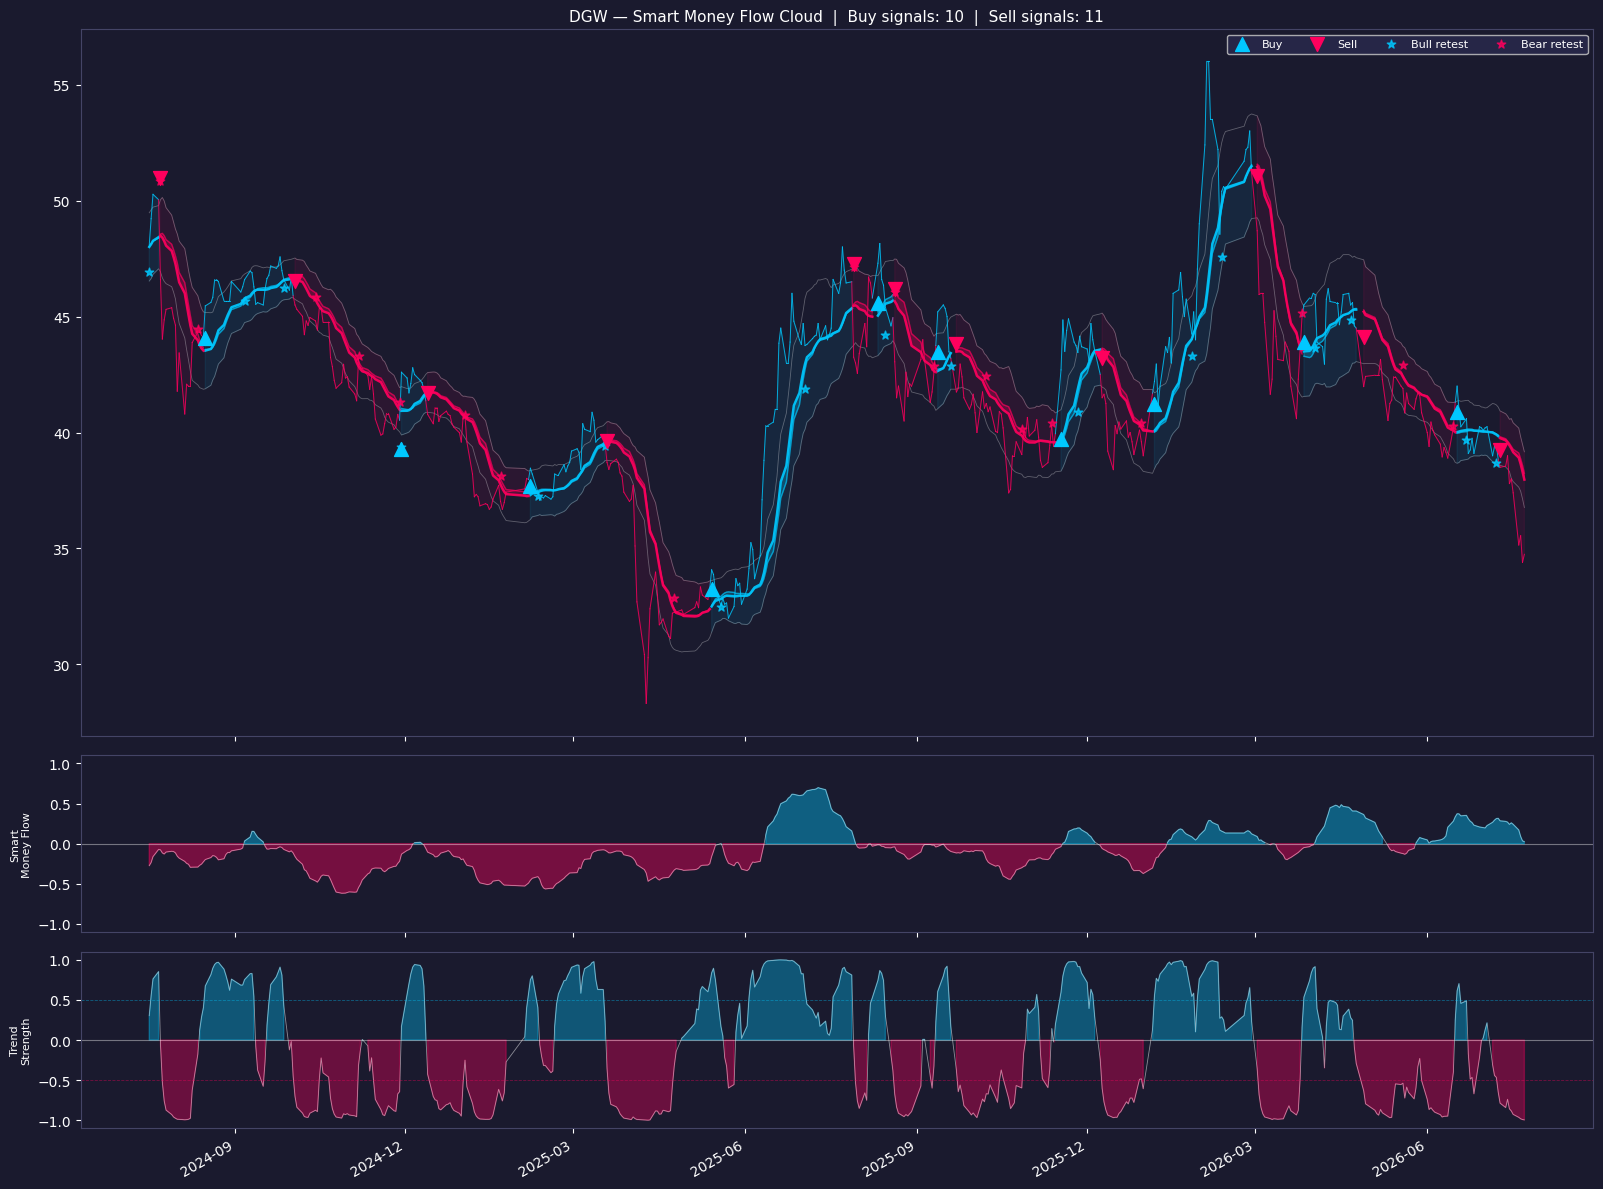


DGW — Latest readings:
  Regime   : BEAR 🔴
  MF Flow  : +0.025
  Strength : 1.2%
  Upper    : 39.17  |  Lower: 36.77
  Trend str: -0.995


In [20]:
# ── Smart Money Flow Cloud — Visualization ────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection
import warnings
warnings.filterwarnings("ignore")

# ── Config ────────────────────────────────────────────────────────────────────
# INSPECT_SYM  = close.columns[0]   # symbol to inspect
TREND_LEN    = 34
BASIS_TYPE_DEFAULT   = 'EMA'              # 'EMA' | 'ALMA'
BASIS_SMOOTH = 3
MF_LEN       = 24
MF_SMOOTH    = 5
MF_POWER     = 1.2
ATR_LEN      = 14
MIN_MULT     = 0.9
MAX_MULT     = 2.2
DOT_COOLDOWN = 12
LOOKBACK     = 504                # bars to show (None = all)
# ─────────────────────────────────────────────────────────────────────────────
def display_smf_cloud(symbol, basis_type=BASIS_TYPE_DEFAULT):

    # Compute for single symbol
    _res = smart_money_flow_cloud(
        open_[[symbol]], high[[symbol]], low[[symbol]],
        close[[symbol]], volume[[symbol]],
        trend_len=TREND_LEN, basis_type=basis_type, basis_smooth=BASIS_SMOOTH,
        mf_len=MF_LEN, mf_smooth=MF_SMOOTH, mf_power=MF_POWER,
        atr_len=ATR_LEN, min_mult=MIN_MULT, max_mult=MAX_MULT,
        dot_cooldown=DOT_COOLDOWN,
    )[symbol]

    # Slice to LOOKBACK
    if LOOKBACK:
        sl = slice(-LOOKBACK, None)
        _r = {k: v.iloc[sl] for k, v in _res.items()}
        _c = close[symbol].iloc[sl]
        _h = high[symbol].iloc[sl]
        _l = low[symbol].iloc[sl]
    else:
        _r = _res
        _c = close[symbol]
        _h = high[symbol]
        _l = low[symbol]

    idx = _c.index
    sig = _r['last_signal'].values
    BULL_C, BEAR_C = '#00C8FF', '#FF005D'
    DARK = '#1a1a2e'

    # ── Plot ──────────────────────────────────────────────────────────────────────
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 12), sharex=True,
        gridspec_kw={'height_ratios': [4, 1, 1]})
    fig.patch.set_facecolor(DARK)
    for ax in (ax1, ax2, ax3):
        ax.set_facecolor(DARK)
        for sp in ax.spines.values(): sp.set_color('#444466')
        ax.tick_params(colors='white')

    # ── Panel 1: Price + Cloud + Bands ───────────────────────────────────────────
    # Basis cloud fill (b_open to b_close), colored by regime
    bull_mask = sig == 1
    for is_bull, color in [(True, BULL_C), (False, BEAR_C)]:
        mask = bull_mask if is_bull else ~bull_mask
        ax1.fill_between(idx, _r['b_open'], _r['b_close'],
                        where=mask, color=color, alpha=0.25, label='_')

    # Adaptive band fills (price vs bands)
    above_lower = _c.values > _r['lower'].values
    below_upper = _c.values < _r['upper'].values
    ax1.fill_between(idx, _c, _r['lower'],
                    where=bull_mask & above_lower, color=BULL_C, alpha=0.08)
    ax1.fill_between(idx, _c, _r['upper'],
                    where=(~bull_mask) & below_upper, color=BEAR_C, alpha=0.08)

    # Band lines
    ax1.plot(idx, _r['upper'], color='white', lw=0.6, alpha=0.3)
    ax1.plot(idx, _r['lower'], color='white', lw=0.6, alpha=0.3)

    # Basis lines (colored by regime)
    for is_bull, color in [(True, BULL_C), (False, BEAR_C)]:
        mask = bull_mask if is_bull else ~bull_mask
        masked_c = np.where(mask, _r['b_close'].values, np.nan)
        masked_o = np.where(mask, _r['b_open'].values,  np.nan)
        ax1.plot(idx, masked_c, color=color, lw=1.8, alpha=0.9)
        ax1.plot(idx, masked_o, color=color, lw=1.0, alpha=0.6)

    # Price line (color-segmented by regime)
    for i in range(1, len(idx)):
        c = BULL_C if sig[i] == 1 else BEAR_C
        ax1.plot(idx[i-1:i+1], _c.values[i-1:i+1], color=c, lw=0.7, alpha=0.8)

    # Buy/Sell labels
    atr_off = (_r['upper'] - _r['lower']).values * 0.08
    up_idx  = np.where(_r['switch_up'].values)[0]
    dn_idx  = np.where(_r['switch_down'].values)[0]
    ax1.scatter(idx[up_idx], _l.values[up_idx] - atr_off[up_idx],
                marker='^', color=BULL_C, s=100, zorder=6, label='Buy')
    ax1.scatter(idx[dn_idx], _h.values[dn_idx] + atr_off[dn_idx],
                marker='v', color=BEAR_C, s=100, zorder=6, label='Sell')

    # Retest dots
    bull_d = np.where(_r['bull_dot'].values)[0]
    bear_d = np.where(_r['bear_dot'].values)[0]
    ax1.scatter(idx[bull_d], _l.values[bull_d] - atr_off[bull_d] * 0.5,
                marker='*', color=BULL_C, s=40, alpha=0.8, zorder=5, label='Bull retest')
    ax1.scatter(idx[bear_d], _h.values[bear_d] + atr_off[bear_d] * 0.5,
                marker='*', color=BEAR_C, s=40, alpha=0.8, zorder=5, label='Bear retest')

    n_buy = len(up_idx); n_sell = len(dn_idx)
    ax1.set_title(
        f'{symbol} — Smart Money Flow Cloud  |  '
        f'Buy signals: {n_buy}  |  Sell signals: {n_sell}',
        color='white', fontsize=11,
    )
    ax1.legend(facecolor='#2a2a4e', labelcolor='white', fontsize=8, ncol=4)

    # ── Panel 2: Smart Money Flow ─────────────────────────────────────────────────
    mf_vals = _r['mf_smooth'].values
    ax2.fill_between(idx, mf_vals, 0,
                    where=mf_vals >= 0, color=BULL_C, alpha=0.4)
    ax2.fill_between(idx, mf_vals, 0,
                    where=mf_vals < 0,  color=BEAR_C, alpha=0.4)
    ax2.plot(idx, mf_vals, color='white', lw=0.6, alpha=0.5)
    ax2.axhline(0, color='white', lw=0.8, alpha=0.4)
    ax2.set_ylabel('Smart\nMoney Flow', color='white', fontsize=8)
    ax2.set_ylim(-1.1, 1.1)

    # ── Panel 3: Trend Strength (signed tanh) ────────────────────────────────────
    str_vals = _r['strength_signed'].values
    ax3.fill_between(idx, str_vals, 0,
                    where=str_vals >= 0, color=BULL_C, alpha=0.35)
    ax3.fill_between(idx, str_vals, 0,
                    where=str_vals < 0,  color=BEAR_C, alpha=0.35)
    ax3.plot(idx, str_vals, color='white', lw=0.6, alpha=0.5)
    ax3.axhline( 0,    color='white',  lw=0.8, alpha=0.4)
    ax3.axhline( 0.5,  color=BULL_C,  lw=0.6, ls='--', alpha=0.4)
    ax3.axhline(-0.5,  color=BEAR_C,  lw=0.6, ls='--', alpha=0.4)
    ax3.set_ylabel('Trend\nStrength', color='white', fontsize=8)
    ax3.set_ylim(-1.1, 1.1)

    # ── X axis ────────────────────────────────────────────────────────────────────
    ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax3.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax3.xaxis.get_majorticklabels(), rotation=30, ha='right', color='white')

    plt.tight_layout()
    plt.show()

    # Latest reading summary
    cur_sig = "BULL 🟢" if _r['last_signal'].iloc[-1] == 1 else "BEAR 🔴"
    print(f"\n{symbol} — Latest readings:")
    print(f"  Regime   : {cur_sig}")
    print(f"  MF Flow  : {_r['mf_smooth'].iloc[-1]:+.3f}")
    print(f"  Strength : {_r['strength'].iloc[-1]:.1%}")
    print(f"  Upper    : {_r['upper'].iloc[-1]:,.2f}  |  Lower: {_r['lower'].iloc[-1]:,.2f}")
    print(f"  Trend str: {_r['strength_signed'].iloc[-1]:+.3f}")


display_smf_cloud('DGW', basis_type='ALMA')

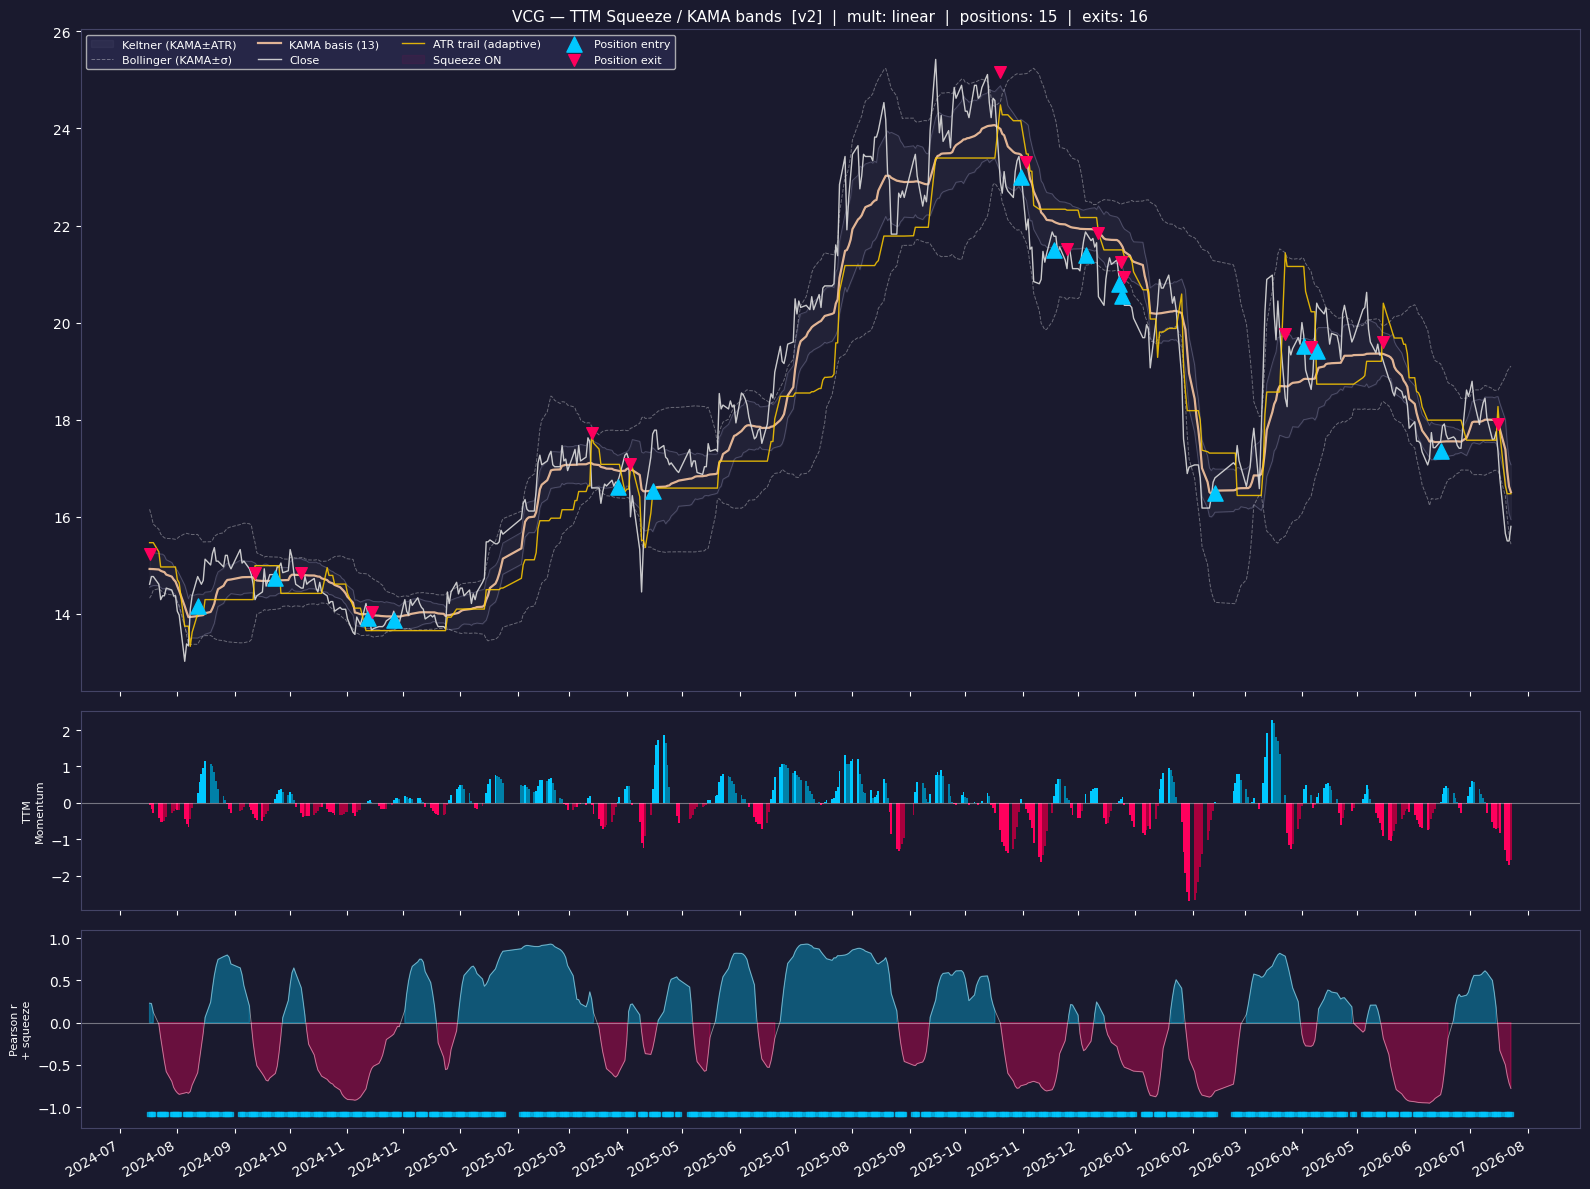


VCG — Latest readings [v2]:
  Close      : 15.80
  KAMA basis : 16.51   BB[15.43, 19.10]   KC[15.94, 17.07]
  Squeeze    : OFF 🟢
  TTM mom    : -1.566
  Pearson r with smooth 5 : -0.778   ->   ATR mult 1.80
  ATR trail  : 16.47
  VCG — TTM/KAMA [v2] performance (vectorbt)
  Total Return : 58.21%
  Sharpe       : 0.436
  Sortino      : 0.641
  Max Drawdown : -48.85%
  # Trades     : 47
  Win Rate     : 19.15%


In [21]:
# ── TTM Squeeze (KAMA bands) — Strategy Visualization ─────────────────────────
# 3-panel dark chart mirroring the SMF-cloud style:
#   Panel 1 : Close + KAMA-centred Bollinger & Keltner + squeeze shading
#             + entry (^) / exit (v) markers + adaptive ATR trailing stop
#   Panel 2 : TTM momentum histogram (4-colour)
#   Panel 3 : Pearson r (drives the adaptive ATR multiplier) + squeeze on/off dots
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")
import talib as _ta

# ─────────────────────────────────────────────────────────────────────────────
ENTRY_VERSION = 'v2'           # 'v1' | 'v2' | 'v3'
LOOKBACK      = 504            # bars to show (None = all)
MULT_MODE     = 'linear'       # 'linear' | 'threshold' | 'slope' | 'slope_threshold'
R_THRESHOLD   = 0.6            # knee for threshold modes
SLOPE_K       = 0.01           # slope% per bar -> ~0.76 strength (slope modes)
R_SMOOTH      = 5              # EMA span on r (1 = off)

# Pull tuned params if a study has run, else sensible defaults.
try:
    _p = best_params.get(ENTRY_VERSION, {})
except NameError:
    _p = {}
P = dict(
    bb_window            = _p.get('bb_window',            16),
    bb_multiplier        = _p.get('bb_multiplier',        1.0),
    kc_window            = _p.get('kc_window',            40),
    kc_multiplier        = _p.get('kc_multiplier',        1.2),
    kc_atr_period        = _p.get('kc_atr_period',        10),
    donichan_window      = _p.get('donichan_window',      10),
    osc_smoothing_period = _p.get('osc_smoothing_period', 10),
    kama_fast            = _p.get('kama_fast',            2),
    kama_slow            = _p.get('kama_slow',            30),
    atr_period           = _p.get('atr_period',           10),
    atr_mult_min         = _p.get('atr_mult_min',         1.5),
    atr_mult_max         = _p.get('atr_mult_max',         3.5),
    corr_window          = _p.get('corr_window',          20),
    low_stop_lookback    = _p.get('low_stop_lookback',    5),
    max_sl               = _p.get('max_sl',               0.08),
    consecutive_neg_threshold = _p.get('consecutive_neg_threshold', 7),
    william_vix_period        = _p.get('william_vix_period',        20),
    r_smooth                  = _p.get('r_smooth',                  5),
)

BULL_C, BEAR_C, DARK = '#00C8FF', '#FF005D', '#1a1a2e'
SQZ_ON_C, SQZ_OFF_C  = '#FF005D', '#00C8FF'
KAMA_C, BAND_C       = '#f7c59f', '#8888aa'


def display_ttm_kama(symbol, version=ENTRY_VERSION):
    c1, h1, l1 = close[[symbol]], high[[symbol]], low[[symbol]]
    o1, v1     = open_[[symbol]], volume[[symbol]]
    cN = c1.to_numpy().astype(np.float64)          # (n, 1)
    hN = h1.to_numpy().ravel().astype(np.float64)
    lN = l1.to_numpy().ravel().astype(np.float64)
    cc = cN.ravel()

    # ── KAMA-centred Bollinger + Keltner ─────────────────────────────────────
    bb_basis = kama_2d(cN, P['bb_window'], P['kama_fast'], P['kama_slow']).ravel()
    bb_std   = _ta.STDDEV(cc, timeperiod=P['bb_window'], nbdev=1.0)
    bb_up    = bb_basis + P['bb_multiplier'] * bb_std
    bb_lo    = bb_basis - P['bb_multiplier'] * bb_std
    atr      = _ta.ATR(hN, lN, cc, timeperiod=P['kc_atr_period'])
    kc_basis = kama_2d(cN, P['kc_window'], P['kama_fast'], P['kama_slow']).ravel()
    kc_up    = kc_basis + P['kc_multiplier'] * atr
    kc_lo    = kc_basis - P['kc_multiplier'] * atr
    sqz_on   = (bb_up < kc_up) & (bb_lo > kc_lo)   # BB inside KC = squeeze

    # ── TTM momentum histogram ───────────────────────────────────────────────
    hh   = _ta.MAX(hN, timeperiod=P['donichan_window'])
    ll   = _ta.MIN(lN, timeperiod=P['donichan_window'])
    sma  = _ta.SMA(cc, timeperiod=P['donichan_window'])
    hist = cc - ((hh + ll) / 2 + sma) / 2
    ttms = _ta.LINEARREG(hist, timeperiod=P['osc_smoothing_period'])

    # ── Pearson r → adaptive ATR trailing stop ───────────────────────────────
    r = pearson_r_2d(cN, P['corr_window']).ravel()
    if R_SMOOTH and R_SMOOTH > 1:
        r = pd.Series(r, index=c1.index).ewm(span=R_SMOOTH, adjust=False).mean().to_numpy()
    lin = np.clip(np.nan_to_num(r, nan=0.0), 0.0, 1.0)
    if MULT_MODE == 'linear':
        scale = lin
    elif MULT_MODE == 'threshold':
        scale = np.clip((lin - R_THRESHOLD) / max(1e-9, 1.0 - R_THRESHOLD), 0.0, 1.0)
    else:  # 'slope' | 'slope_threshold'
        _slp     = _ta.LINEARREG_SLOPE(cc, timeperiod=P['corr_window'])
        _slp_pct = np.nan_to_num(_slp / cc, nan=0.0)
        _slp_scl = np.clip(np.tanh(_slp_pct / SLOPE_K), 0.0, 1.0)
        if MULT_MODE == 'slope':
            scale = lin * _slp_scl
        else:
            _thr  = np.clip((lin - R_THRESHOLD) / max(1e-9, 1.0 - R_THRESHOLD), 0.0, 1.0)
            scale = _thr * _slp_scl
    mult  = P['atr_mult_min'] + (P['atr_mult_max'] - P['atr_mult_min']) * scale
    atr_p = _ta.ATR(hN, lN, cc, timeperiod=P['atr_period'])
    trail = atr_trailing_adaptive_nb(cN, atr_p.reshape(-1, 1), mult.reshape(-1, 1)).ravel()

    # ── entry / exit signals via the real strategy functions ─────────────────
    entries_df = compute_signals(
        c1, h1, l1, o1, v1, entry_version=version,
        bb_window=P['bb_window'], bb_multiplier=P['bb_multiplier'],
        kc_window=P['kc_window'], kc_multiplier=P['kc_multiplier'],
        kc_atr_period=P['kc_atr_period'], donichan_window=P['donichan_window'],
        osc_smoothing_period=P['osc_smoothing_period'],
        kama_fast=P['kama_fast'], kama_slow=P['kama_slow'],
        consecutive_neg_threshold=P['consecutive_neg_threshold'],
        william_vix_period=P['william_vix_period'],
    )[[symbol]]
    exits_df, sl_stop_df = compute_exits(
        o1, c1, h1, l1, v1,
        atr_period=P['atr_period'], low_stop_lookback=P['low_stop_lookback'],
        max_sl=P['max_sl'], atr_mult_min=P['atr_mult_min'],
        atr_mult_max=P['atr_mult_max'], corr_window=P['corr_window'],
        mult_mode=MULT_MODE, r_threshold=R_THRESHOLD, slope_k=SLOPE_K, r_smooth=R_SMOOTH,
    )
    exits_df = exits_df[[symbol]]
    entries  = entries_df.to_numpy().ravel()
    exits    = exits_df.to_numpy().ravel()

    # ── actual vectorbt positions (one-at-a-time entry + adaptive ATR sl_stop) ─
    # Raw signals != trades: vbt ignores entries while already long and exits via
    # the sl_stop, so plot the real entry/exit bars taken by the portfolio.
    pf_sym = vbt.Portfolio.from_signals(
        close=c1, entries=entries_df, exits=exits_df,
        freq='1d', group_by=['symbol'], cash_sharing=False, sl_stop=sl_stop_df,
    )
    _rec        = pf_sym.trades.records
    pos_entry_i = np.asarray(_rec['entry_idx'], dtype=int)
    # vbt fills an OPEN trade's exit_idx with the last bar -> not a real exit.
    # Keep exit markers for CLOSED trades only (status == 1).
    _closed     = np.asarray(_rec['status'], dtype=int) == 1
    pos_exit_i  = np.asarray(_rec['exit_idx'], dtype=int)[_closed]
    n_full      = len(cc)

    # ── slice to LOOKBACK ────────────────────────────────────────────────────
    s   = slice(-LOOKBACK, None) if LOOKBACK else slice(None)
    idx = c1.index[s]
    (cc, bb_up, bb_lo, kc_up, kc_lo, kc_basis, sqz_on, ttms, r, mult,
     trail, entries, exits, hN, lN) = [a[s] for a in (
        cc, bb_up, bb_lo, kc_up, kc_lo, kc_basis, sqz_on, ttms, r, mult,
        trail, entries, exits, hN, lN)]

    # map full-series trade positions into the sliced window
    _off        = n_full - len(cc)
    pos_entry_i = pos_entry_i - _off
    pos_exit_i  = pos_exit_i  - _off
    pos_entry_i = pos_entry_i[(pos_entry_i >= 0) & (pos_entry_i < len(cc))]
    pos_exit_i  = pos_exit_i[(pos_exit_i  >= 0) & (pos_exit_i  < len(cc))]

    # ── plot ─────────────────────────────────────────────────────────────────
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 12), sharex=True,
        gridspec_kw={'height_ratios': [4, 1.2, 1.2]})
    fig.patch.set_facecolor(DARK)
    for ax in (ax1, ax2, ax3):
        ax.set_facecolor(DARK)
        for sp in ax.spines.values(): sp.set_color('#444466')
        ax.tick_params(colors='white')

    # Panel 1 — price + bands + signals
    ax1.fill_between(idx, kc_up, kc_lo, color=BAND_C, alpha=0.08, label='Keltner (KAMA±ATR)')
    ax1.plot(idx, kc_up, color=BAND_C, lw=0.7, alpha=0.4)
    ax1.plot(idx, kc_lo, color=BAND_C, lw=0.7, alpha=0.4)
    ax1.plot(idx, bb_up, color='white', lw=0.7, alpha=0.35, ls='--', label='Bollinger (KAMA±σ)')
    ax1.plot(idx, bb_lo, color='white', lw=0.7, alpha=0.35, ls='--')
    ax1.plot(idx, kc_basis, color=KAMA_C, lw=1.6, alpha=0.9, label=f"KAMA basis ({P['kc_window']})")
    ax1.plot(idx, cc, color='#dddddd', lw=1.0, alpha=0.9, label='Close')
    ax1.plot(idx, trail, color='#ffcc00', lw=1.0, alpha=0.85, label='ATR trail (adaptive)')
    ax1.fill_between(idx, 0, 1, where=sqz_on, transform=ax1.get_xaxis_transform(),
                     color=SQZ_ON_C, alpha=0.06, label='Squeeze ON')

    e_i, x_i = pos_entry_i, pos_exit_i
    off = (kc_up - kc_lo) * 0.10
    ax1.scatter(idx[e_i], lN[e_i] - off[e_i], marker='^', color=BULL_C, s=120, zorder=6, label='Position entry')
    ax1.scatter(idx[x_i], hN[x_i] + off[x_i], marker='v', color=BEAR_C, s=70,  zorder=6, label='Position exit')

    ax1.set_title(
        f'{symbol} — TTM Squeeze / KAMA bands  [{version}]  |  mult: {MULT_MODE}  |  '
        f'positions: {len(e_i)}  |  exits: {len(x_i)}',
        color='white', fontsize=11)
    ax1.legend(facecolor='#2a2a4e', labelcolor='white', fontsize=8, ncol=4, loc='upper left')

    # Panel 2 — TTM momentum histogram (classic 4-colour)
    rising = np.r_[np.nan, np.diff(ttms)] >= 0
    bar_c  = np.where(ttms >= 0,
                      np.where(rising, '#00C8FF', '#0080A8'),
                      np.where(rising, '#A8003D', '#FF005D'))
    ax2.bar(idx, ttms, color=bar_c, width=1.0, align='center')
    ax2.axhline(0, color='white', lw=0.8, alpha=0.4)
    ax2.set_ylabel('TTM\nMomentum', color='white', fontsize=8)

    # Panel 3 — Pearson r (adaptive-mult driver) + squeeze dots
    ax3.fill_between(idx, r, 0, where=r >= 0, color=BULL_C, alpha=0.35)
    ax3.fill_between(idx, r, 0, where=r < 0,  color=BEAR_C, alpha=0.35)
    ax3.plot(idx, r, color='white', lw=0.6, alpha=0.5)
    ax3.axhline(0, color='white', lw=0.8, alpha=0.4)
    ax3.scatter(idx, np.full(len(idx), -1.08), marker='s', s=10,
                color=np.where(sqz_on, SQZ_ON_C, SQZ_OFF_C), alpha=0.7)
    ax3.set_ylabel('Pearson r\n+ squeeze', color='white', fontsize=8)
    ax3.set_ylim(-1.25, 1.1)

    ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax3.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    plt.setp(ax3.xaxis.get_majorticklabels(), rotation=30, ha='right', color='white')
    plt.tight_layout()
    plt.show()

    # ── summary ──────────────────────────────────────────────────────────────
    print(f"\n{symbol} — Latest readings [{version}]:")
    print(f"  Close      : {cc[-1]:,.2f}")
    print(f"  KAMA basis : {kc_basis[-1]:,.2f}   BB[{bb_lo[-1]:,.2f}, {bb_up[-1]:,.2f}]   KC[{kc_lo[-1]:,.2f}, {kc_up[-1]:,.2f}]")
    print(f"  Squeeze    : {'ON 🔴' if sqz_on[-1] else 'OFF 🟢'}")
    print(f"  TTM mom    : {ttms[-1]:+.3f}")
    print(f"  Pearson r with smooth {P['r_smooth']} : {r[-1]:+.3f}   ->   ATR mult {mult[-1]:.2f}")
    print(f"  ATR trail  : {trail[-1]:,.2f}")

def compute_metrics(symbol, version=ENTRY_VERSION):
    _entries_pf = compute_signals(
    close[[symbol]], high[[symbol]], low[[symbol]], open_[[symbol]], volume[[symbol]],
    entry_version=ENTRY_VERSION,
    bb_window=P['bb_window'], bb_multiplier=P['bb_multiplier'],
    kc_window=P['kc_window'], kc_multiplier=P['kc_multiplier'],
    kc_atr_period=P['kc_atr_period'], donichan_window=P['donichan_window'],
    osc_smoothing_period=P['osc_smoothing_period'],
    kama_fast=P['kama_fast'], kama_slow=P['kama_slow'],
    consecutive_neg_threshold=P['consecutive_neg_threshold'],
    william_vix_period=P['william_vix_period'],
)
    _exits_pf, _sl_stop_pf = compute_exits(
        open_[[symbol]], close[[symbol]], high[[symbol]], low[[symbol]], volume[[symbol]],
        atr_period=P['atr_period'], low_stop_lookback=P['low_stop_lookback'],
        max_sl=P['max_sl'], atr_mult_min=P['atr_mult_min'],
        atr_mult_max=P['atr_mult_max'], corr_window=P['corr_window'],
        r_smooth=5
    )

    pf_sym = vbt.Portfolio.from_signals(
        close=close[[symbol]], entries=_entries_pf, exits=_exits_pf,
        freq='1d', group_by=['symbol'], cash_sharing=False, sl_stop=_sl_stop_pf,
    )

    print('=' * 52)
    print(f'  {symbol} — TTM/KAMA [{ENTRY_VERSION}] performance (vectorbt)')
    print('=' * 52)
    # print(pf_sym.stats())

    # key headline numbers
    def _v(x):
        return float(np.atleast_1d(x)[0])
    print(f'  Total Return : {_v(pf_sym.total_return()):.2%}')
    print(f'  Sharpe       : {_v(pf_sym.sharpe_ratio()):.3f}')
    print(f'  Sortino      : {_v(pf_sym.sortino_ratio()):.3f}')
    print(f'  Max Drawdown : {_v(pf_sym.max_drawdown()):.2%}')
    print(f'  # Trades     : {int(pf_sym.trades.count().sum())}')
    print(f'  Win Rate     : {_v(pf_sym.trades.win_rate()):.2%}')


# ── Config ────────────────────────────────────────────────────────────────────
INSPECT_SYM   = 'VCG'          # symbol to inspect

display_ttm_kama(INSPECT_SYM, version=ENTRY_VERSION)
compute_metrics(INSPECT_SYM, version=ENTRY_VERSION)